In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
!git clone https://github.com/WongKinYiu/yolov9.git /kaggle/working/yolov9
%cd /kaggle/working/yolov9

!ls

Cloning into '/kaggle/working/yolov9'...
remote: Enumerating objects: 781, done.
remote: Total 781 (delta 0), reused 0 (delta 0), pack-reused 781 (from 1)
Receiving objects: 100% (781/781), 3.27 MiB | 11.55 MiB/s, done.
Resolving deltas: 100% (330/330), done.
/kaggle/working/yolov9
benchmarks.py	export.py   panoptic	      tools	       val_dual.py
classify	figure	    README.md	      train_dual.py    val.py
data		hubconf.py  requirements.txt  train.py	       val_triple.py
detect_dual.py	LICENSE.md  scripts	      train_triple.py
detect.py	models	    segment	      utils


In [2]:
%cd /kaggle/working/yolov9

from pathlib import Path

src = Path("models/detect/yolov9-c.yaml")
dst = Path("models/detect/yolov9-c-mwpd-enhanced.yaml")

text = src.read_text()

# Selected ADown → standard Conv replacements
replacements = {
    "[-1, 1, ADown, [256]], # 4-P3/8":
        "[-1, 1, Conv, [256, 3, 2]], # 4-P3/8",

    "[-1, 1, ADown, [512]], # 6-P4/16":
        "[-1, 1, Conv, [512, 3, 2]], # 6-P4/16",

    "[-1, 1, ADown, [512]], # 8-P5/32":
        "[-1, 1, Conv, [512, 3, 2]], # 8-P5/32",

    "[-1, 1, ADown, [256]],":
        "[-1, 1, Conv, [256, 3, 2]],",

    "[-1, 1, ADown, [512]],":
        "[-1, 1, Conv, [512, 3, 2]],",
}

for old, new in replacements.items():
    text = text.replace(old, new)

dst.write_text(text)

print("Created:", dst)
print("\nRemaining ADown layers:")
for i, line in enumerate(text.splitlines(), 1):
    if "ADown" in line:
        print(i, line)

/kaggle/working/yolov9
Created: models/detect/yolov9-c-mwpd-enhanced.yaml

Remaining ADown layers:


In [4]:
%cd /kaggle/working/yolov9

from pathlib import Path

src = Path("models/detect/yolov9-c.yaml")
dst = Path("models/detect/yolov9-c-mwpd-enhanced.yaml")

text = src.read_text()

# Replace ONLY the first five ADown occurrences.
# Keep the final three ADown layers unchanged.
old = "ADown"
lines = text.splitlines()

count = 0
for i, line in enumerate(lines):
    if "ADown" in line and count < 5:
        lines[i] = line.replace(
            "ADown, [256]",
            "Conv, [256, 3, 2]"
        ).replace(
            "ADown, [512]",
            "Conv, [512, 3, 2]"
        )
        count += 1

new_text = "\n".join(lines) + "\n"
dst.write_text(new_text)

print("Replaced ADown layers:", count)
print("\nRemaining ADown layers:")

for i, line in enumerate(new_text.splitlines(), 1):
    if "ADown" in line:
        print(i, line)

/kaggle/working/yolov9
Replaced ADown layers: 5

Remaining ADown layers:
98    [-1, 1, ADown, [256]],  # 29-P3/8
105    [-1, 1, ADown, [512]],  # 32-P4/16
112    [-1, 1, ADown, [512]],  # 35-P5/32


In [7]:
%cd /kaggle/working/yolov9

# Backup files before modifying
!cp train_dual.py train_dual.py.bak
!cp utils/general.py utils/general.py.bak
!cp models/experimental.py models/experimental.py.bak
!cp utils/plots.py utils/plots.py.bak

# PyTorch 2.6+ checkpoint loading
!sed -i "s/torch.load(weights, map_location='cpu')/torch.load(weights, map_location='cpu', weights_only=False)/" train_dual.py

!sed -i "s/torch.load(f, map_location=torch.device('cpu'))/torch.load(f, map_location=torch.device('cpu'), weights_only=False)/" utils/general.py

!sed -i "s/torch.load(attempt_download(w), map_location='cpu')/torch.load(attempt_download(w), map_location='cpu', weights_only=False)/" models/experimental.py

# Pillow compatibility: getsize → getbbox
!sed -i "s/font.getsize(label)/((font.getbbox(label)[2] - font.getbbox(label)[0]), (font.getbbox(label)[3] - font.getbbox(label)[1]))/g" utils/plots.py

print("Compatibility fixes applied.")

/kaggle/working/yolov9
Compatibility fixes applied.


In [8]:
%cd /kaggle/working/yolov9

from pathlib import Path

data_yaml = Path("/kaggle/working/yolov9/data_mwpd.yaml")

data_yaml.write_text("""train: /kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/train/images
val: /kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/valid/images
test: /kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/test/images

nc: 1
names: ['Potholes']
""")

print(data_yaml.read_text())

/kaggle/working/yolov9
train: /kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/train/images
val: /kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/valid/images
test: /kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/test/images

nc: 1
names: ['Potholes']



In [9]:
%cd /kaggle/working/yolov9

!python train_dual.py \
    --weights yolov9-c.pt \
    --cfg models/detect/yolov9-c-mwpd-enhanced.yaml \
    --data data_mwpd.yaml \
    --hyp data/hyps/hyp.scratch-high.yaml \
    --epochs 1 \
    --batch-size 4 \
    --imgsz 640 \
    --device 0 \
    --workers 4 \
    --optimizer SGD \
    --name MWPD_YOLOv9_Enhanced_SMOKE \
    --project /kaggle/working/runs \
    --exist-ok

/kaggle/working/yolov9
/kaggle/working/yolov9/utils/general.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg
Traceback (most recent call last):
  File "/kaggle/working/yolov9/train_dual.py", line 25, in <module>
    import val_dual as validate  # for end-of-epoch mAP
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/kaggle/working/yolov9/val_dual.py", line 17, in <module>
    from models.common import DetectMultiBackend
  File "/kaggle/working/yolov9/models/common.py", line 30, in <module>
    from utils.plots import Annotator, colors, save_one_box
  File "/kaggle/working/yolov9/utils/plots.py", line 86
    w, h = self.((font.getbbox(label)[2] - font.getbbox(label)[0]), (font.getbbox(label)[3] - font.getbbox(label)[1]))  # text width, height
                ^
SyntaxErr

In [10]:
%cd /kaggle/working/yolov9

# Restore the original plots.py
!cp utils/plots.py.bak utils/plots.py

print("plots.py restored.")

/kaggle/working/yolov9
plots.py restored.


In [11]:
%cd /kaggle/working/yolov9

# Show the relevant sections
!sed -n '75,95p' utils/plots.py
!sed -n '155,175p' utils/plots.py

/kaggle/working/yolov9
            self.font = check_pil_font(font='Arial.Unicode.ttf' if non_ascii else font,
                                       size=font_size or max(round(sum(self.im.size) / 2 * 0.035), 12))
        else:  # use cv2
            self.im = im
        self.lw = line_width or max(round(sum(im.shape) / 2 * 0.003), 2)  # line width

    def box_label(self, box, label='', color=(128, 128, 128), txt_color=(255, 255, 255)):
        # Add one xyxy box to image with label
        if self.pil or not is_ascii(label):
            self.draw.rectangle(box, width=self.lw, outline=color)  # box
            if label:
                w, h = self.((font.getbbox(label)[2] - font.getbbox(label)[0]), (font.getbbox(label)[3] - font.getbbox(label)[1]))  # text width, height
                outside = box[1] - h >= 0  # label fits outside box
                self.draw.rectangle(
                    (box[0], box[1] - h if outside else box[1], box[0] + w + 1,
                     box[1] + 1 

In [12]:
%cd /kaggle/working/yolov9

from pathlib import Path

path = Path("utils/plots.py")
text = path.read_text()

# Fix corrupted box_label line
text = text.replace(
    "w, h = self.((font.getbbox(label)[2] - font.getbbox(label)[0]), "
    "(font.getbbox(label)[3] - font.getbbox(label)[1]))",
    "bbox = font.getbbox(label)\n                w, h = bbox[2] - bbox[0], bbox[3] - bbox[1]"
)

# Fix remaining Pillow getsize() usage
text = text.replace(
    "w, h = self.font.getsize(text)  # text width, height",
    "bbox = self.font.getbbox(text)\n            w, h = bbox[2] - bbox[0], bbox[3] - bbox[1]  # text width, height"
)

path.write_text(text)

print("plots.py fixed.")

/kaggle/working/yolov9
plots.py fixed.


In [13]:
%cd /kaggle/working/yolov9

import py_compile

py_compile.compile("utils/plots.py", doraise=True)

print("✅ utils/plots.py syntax check passed")

/kaggle/working/yolov9
✅ utils/plots.py syntax check passed


In [14]:
%cd /kaggle/working/yolov9

!python train_dual.py \
    --weights yolov9-c.pt \
    --cfg models/detect/yolov9-c-mwpd-enhanced.yaml \
    --data data_mwpd.yaml \
    --hyp data/hyps/hyp.scratch-high.yaml \
    --epochs 1 \
    --batch-size 4 \
    --imgsz 640 \
    --device 0 \
    --workers 4 \
    --optimizer SGD \
    --name MWPD_YOLOv9_Enhanced_SMOKE \
    --project /kaggle/working/runs \
    --exist-ok

/kaggle/working/yolov9
/kaggle/working/yolov9/utils/general.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 
wandb: WARNING W&B disabled due to login timeout.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
train_dual: weights=yolov9-c.pt, cfg=models/detect/yolov9-c-mwpd-enhanced.yaml, data=data_mwpd.yaml, hyp=data/hyps/hyp.scratch-high.yaml, epochs=1, batch_size=4, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, bucket=, cache=None, image_weights=False, device=0, multi_scale=False, single_cls=False, optimizer=SGD

In [15]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("⚠️ GPU is NOT available in this session.")

PyTorch: 2.11.0+cpu
CUDA available: False
CUDA device count: 0
⚠️ GPU is NOT available in this session.


In [1]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
CUDA device count: 2
GPU: Tesla T4


In [2]:
%cd /kaggle/working/yolov9

from pathlib import Path
import torch

print("YOLOv9 directory:", Path(".").exists())
print("Enhanced YAML:", Path("models/detect/yolov9-c-mwpd-enhanced.yaml").exists())
print("MWPD YAML:", Path("data_mwpd.yaml").exists())
print("train_dual.py:", Path("train_dual.py").exists())
print("plots.py:", Path("utils/plots.py").exists())

print("\nGPU:")
print("CUDA:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())
print("GPU 0:", torch.cuda.get_device_name(0))

[Errno 2] No such file or directory: '/kaggle/working/yolov9'
/kaggle/working
YOLOv9 directory: True
Enhanced YAML: False
MWPD YAML: False
train_dual.py: False
plots.py: False

GPU:
CUDA: True
GPU count: 2
GPU 0: Tesla T4


In [3]:
!git clone https://github.com/WongKinYiu/yolov9.git /kaggle/working/yolov9
%cd /kaggle/working/yolov9

Cloning into '/kaggle/working/yolov9'...
remote: Enumerating objects: 781, done.
remote: Total 781 (delta 0), reused 0 (delta 0), pack-reused 781 (from 1)
Receiving objects: 100% (781/781), 3.27 MiB | 11.67 MiB/s, done.
Resolving deltas: 100% (330/330), done.
/kaggle/working/yolov9


In [4]:
!ls

benchmarks.py	export.py   panoptic	      tools	       val_dual.py
classify	figure	    README.md	      train_dual.py    val.py
data		hubconf.py  requirements.txt  train.py	       val_triple.py
detect_dual.py	LICENSE.md  scripts	      train_triple.py
detect.py	models	    segment	      utils


In [5]:
%cd /kaggle/working/yolov9

from pathlib import Path

src = Path("models/detect/yolov9-c.yaml")
dst = Path("models/detect/yolov9-c-mwpd-enhanced.yaml")

lines = src.read_text().splitlines()

replaced = 0

for i, line in enumerate(lines):
    if "ADown" in line and replaced < 5:
        if "[256]" in line:
            lines[i] = line.replace(
                "ADown, [256]",
                "Conv, [256, 3, 2]"
            )
        elif "[512]" in line:
            lines[i] = line.replace(
                "ADown, [512]",
                "Conv, [512, 3, 2]"
            )
        replaced += 1

dst.write_text("\n".join(lines) + "\n")

print("Replaced ADown layers:", replaced)
print("\nRemaining ADown layers:")

for i, line in enumerate(lines, 1):
    if "ADown" in line:
        print(i, line)

/kaggle/working/yolov9
Replaced ADown layers: 5

Remaining ADown layers:
98    [-1, 1, ADown, [256]],  # 29-P3/8
105    [-1, 1, ADown, [512]],  # 32-P4/16
112    [-1, 1, ADown, [512]],  # 35-P5/32


In [6]:
%cd /kaggle/working/yolov9

from pathlib import Path

Path("data_mwpd.yaml").write_text("""train: /kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/train/images
val: /kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/valid/images
test: /kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/test/images

nc: 1
names: ['Potholes']
""")

print(Path("data_mwpd.yaml").read_text())

/kaggle/working/yolov9
train: /kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/train/images
val: /kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/valid/images
test: /kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/test/images

nc: 1
names: ['Potholes']



In [7]:
%cd /kaggle/working/yolov9

from pathlib import Path

# ---------- 1. train_dual.py ----------
p = Path("train_dual.py")
text = p.read_text()

text = text.replace(
    "torch.load(weights, map_location='cpu')",
    "torch.load(weights, map_location='cpu', weights_only=False)"
)

p.write_text(text)


# ---------- 2. utils/general.py ----------
p = Path("utils/general.py")
text = p.read_text()

text = text.replace(
    "torch.load(f, map_location=torch.device('cpu'))",
    "torch.load(f, map_location=torch.device('cpu'), weights_only=False)"
)

p.write_text(text)


# ---------- 3. models/experimental.py ----------
p = Path("models/experimental.py")
text = p.read_text()

text = text.replace(
    "torch.load(attempt_download(w), map_location='cpu')",
    "torch.load(attempt_download(w), map_location='cpu', weights_only=False)"
)

p.write_text(text)


print("✅ PyTorch checkpoint-loading fixes applied.")

/kaggle/working/yolov9
✅ PyTorch checkpoint-loading fixes applied.


In [8]:
import py_compile

files = [
    "train_dual.py",
    "utils/general.py",
    "models/experimental.py",
]

for f in files:
    py_compile.compile(f, doraise=True)
    print("✅", f)

✅ train_dual.py
✅ utils/general.py
✅ models/experimental.py


In [9]:
%cd /kaggle/working/yolov9

!python train_dual.py \
    --weights yolov9-c.pt \
    --cfg models/detect/yolov9-c-mwpd-enhanced.yaml \
    --data data_mwpd.yaml \
    --hyp data/hyps/hyp.scratch-high.yaml \
    --epochs 1 \
    --batch-size 4 \
    --imgsz 640 \
    --device 0 \
    --workers 4 \
    --optimizer SGD \
    --name MWPD_YOLOv9_Enhanced_SMOKE \
    --project /kaggle/working/runs \
    --exist-ok

/kaggle/working/yolov9
/kaggle/working/yolov9/utils/general.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 
wandb: WARNING W&B disabled due to login timeout.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
train_dual: weights=yolov9-c.pt, cfg=models/detect/yolov9-c-mwpd-enhanced.yaml, data=data_mwpd.yaml, hyp=data/hyps/hyp.scratch-high.yaml, epochs=1, batch_size=4, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, bucket=, cache=None, image_weights=False, device=0, multi_scale=False, single_cls=False, optimizer=SGD

In [10]:
%cd /kaggle/working/yolov9

!wget -q --show-progress \
    https://github.com/WongKinYiu/yolov9/releases/download/v0.1/yolov9-c.pt \
    -O yolov9-c.pt

import os

print("\nWeights exist:", os.path.exists("yolov9-c.pt"))
print("Size (MB):", round(os.path.getsize("yolov9-c.pt") / (1024**2), 2))

/kaggle/working/yolov9
yolov9-c.pt         100%[===================>]  98.37M  94.6MB/s    in 1.0s    

Weights exist: True
Size (MB): 98.37


In [11]:
%cd /kaggle/working/yolov9

!wget -q --show-progress \
    https://github.com/WongKinYiu/yolov9/releases/download/v0.1/yolov9-c.pt \
    -O yolov9-c.pt

import os

print("\nWeights exist:", os.path.exists("yolov9-c.pt"))
print("Size (MB):", round(os.path.getsize("yolov9-c.pt") / (1024**2), 2))

/kaggle/working/yolov9
yolov9-c.pt         100%[===================>]  98.37M   178MB/s    in 0.6s    

Weights exist: True
Size (MB): 98.37


In [12]:
%cd /kaggle/working/yolov9

!python train_dual.py \
    --weights yolov9-c.pt \
    --cfg models/detect/yolov9-c-mwpd-enhanced.yaml \
    --data data_mwpd.yaml \
    --hyp data/hyps/hyp.scratch-high.yaml \
    --epochs 1 \
    --batch-size 4 \
    --imgsz 640 \
    --device 0 \
    --workers 4 \
    --optimizer SGD \
    --name MWPD_YOLOv9_Enhanced_SMOKE \
    --project /kaggle/working/runs \
    --exist-ok

/kaggle/working/yolov9
/kaggle/working/yolov9/utils/general.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 
wandb: WARNING W&B disabled due to login timeout.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
train_dual: weights=yolov9-c.pt, cfg=models/detect/yolov9-c-mwpd-enhanced.yaml, data=data_mwpd.yaml, hyp=data/hyps/hyp.scratch-high.yaml, epochs=1, batch_size=4, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, bucket=, cache=None, image_weights=False, device=0, multi_scale=False, single_cls=False, optimizer=SGD

In [13]:
%cd /kaggle/working/yolov9

from pathlib import Path

path = Path("utils/plots.py")
lines = path.read_text().splitlines()

# Fix the exact line inside box_label()
for i, line in enumerate(lines):
    if "w, h = self.font.getsize(label)" in line:
        indent = line[:len(line) - len(line.lstrip())]
        lines[i] = indent + "bbox = self.font.getbbox(label)"
        lines.insert(i + 1, indent + "w, h = bbox[2] - bbox[0], bbox[3] - bbox[1]")
        print("Fixed box_label() at line", i + 1)

# Fix the exact line inside text()
for i, line in enumerate(lines):
    if "w, h = self.font.getsize(text)" in line:
        indent = line[:len(line) - len(line.lstrip())]
        lines[i] = indent + "bbox = self.font.getbbox(text)"
        lines.insert(i + 1, indent + "w, h = bbox[2] - bbox[0], bbox[3] - bbox[1]  # text width, height"
        )
        print("Fixed text() at line", i + 1)

path.write_text("\n".join(lines) + "\n")

/kaggle/working/yolov9
Fixed box_label() at line 86
Fixed text() at line 166


25300

In [14]:
import py_compile

py_compile.compile("utils/plots.py", doraise=True)

text = open("utils/plots.py").read()

print("✅ plots.py syntax valid")
print("Remaining label getsize:", text.count("getsize(label)"))
print("Remaining text getsize:", text.count("getsize(text)"))

✅ plots.py syntax valid
Remaining label getsize: 0
Remaining text getsize: 0


In [15]:
%cd /kaggle/working/yolov9

!python train_dual.py \
    --weights yolov9-c.pt \
    --cfg models/detect/yolov9-c-mwpd-enhanced.yaml \
    --data data_mwpd.yaml \
    --hyp data/hyps/hyp.scratch-high.yaml \
    --epochs 1 \
    --batch-size 4 \
    --imgsz 640 \
    --device 0 \
    --workers 4 \
    --optimizer SGD \
    --name MWPD_YOLOv9_Enhanced_SMOKE \
    --project /kaggle/working/runs \
    --exist-ok

/kaggle/working/yolov9
/kaggle/working/yolov9/utils/general.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 
wandb: WARNING W&B disabled due to login timeout.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
train_dual: weights=yolov9-c.pt, cfg=models/detect/yolov9-c-mwpd-enhanced.yaml, data=data_mwpd.yaml, hyp=data/hyps/hyp.scratch-high.yaml, epochs=1, batch_size=4, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, bucket=, cache=None, image_weights=False, device=0, multi_scale=False, single_cls=False, optimizer=SGD

In [ ]:
print("Model 2 training already completed.")
print("Using the previously trained Enhanced YOLOv9 checkpoint.")

/kaggle/working/yolov9
/kaggle/working/yolov9/utils/general.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 
wandb: WARNING W&B disabled due to login timeout.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
train_dual: weights=yolov9-c.pt, cfg=models/detect/yolov9-c-mwpd-enhanced.yaml, data=data_mwpd.yaml, hyp=data/hyps/hyp.scratch-high.yaml, epochs=100, batch_size=4, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, bucket=, cache=None, image_weights=False, device=0, multi_scale=False, single_cls=False, optimizer=S

In [17]:
!ls -lh /kaggle/working/runs/MWPD_YOLOv9_Enhanced/weights/

total 873M
-rw-r--r-- 1 root root 437M Oct  7 09:27 best.pt
-rw-r--r-- 1 root root 437M Oct  7 09:56 last.pt


In [18]:
!cp /kaggle/working/runs/MWPD_YOLOv9_Enhanced/weights/last.pt \
/kaggle/working/Model2_last.pt

!cp /kaggle/working/runs/MWPD_YOLOv9_Enhanced/weights/best.pt \
/kaggle/working/Model2_best.pt

!ls -lh /kaggle/working/Model2_*.pt

-rw-r--r-- 1 root root 437M Oct  7 10:16 /kaggle/working/Model2_best.pt
-rw-r--r-- 1 root root 437M Oct  7 10:16 /kaggle/working/Model2_last.pt


In [19]:
!ls -lh /kaggle/working/Model2_last.pt

-rw-r--r-- 1 root root 437M Oct  7 10:16 /kaggle/working/Model2_last.pt


In [20]:
import torch

ckpt = torch.load(
    "/kaggle/working/Model2_last.pt",
    map_location="cpu",
    weights_only=False
)

print("Checkpoint type:", type(ckpt))
print("Saved epoch:", ckpt.get("epoch"))
print("Best fitness:", ckpt.get("best_fitness"))
print("Optimizer saved:", ckpt.get("optimizer") is not None)

/kaggle/working/yolov9/utils/general.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg


Checkpoint type: <class 'dict'>
Saved epoch: 76
Best fitness: [    0.46388]
Optimizer saved: True


In [21]:
!ls -lh /kaggle/working/runs/MWPD_YOLOv9_Enhanced/opt.yaml

-rw-r--r-- 1 root root 1.2K Oct  7 03:42 /kaggle/working/runs/MWPD_YOLOv9_Enhanced/opt.yaml


In [22]:
%cd /kaggle/working/yolov9

!python train_dual.py \
    --resume /kaggle/working/runs/MWPD_YOLOv9_Enhanced/weights/last.pt

/kaggle/working/yolov9
/kaggle/working/yolov9/utils/general.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice: (30 second timeout) 
wandb: WARNING W&B disabled due to login timeout.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin
train_dual: weights=, cfg=yolo.yaml, data=data/coco.yaml, hyp=data/hyps/hyp.scratch-high.yaml, epochs=100, batch_size=16, imgsz=640, rect=False, resume=/kaggle/working/runs/MWPD_YOLOv9_Enhanced/weights/last.pt, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, bucket=, cache=None, image_weights=False, device=, multi_scale=False, single_cls=False, op

In [25]:
!ls -lh /kaggle/working/runs/MWPD_YOLOv9_Enhanced/weights/

total 219M
-rw-r--r-- 1 root root 110M Oct  7 12:12 best.pt
-rw-r--r-- 1 root root 110M Oct  7 12:12 last.pt


In [26]:
import os
from pathlib import Path

baseline = Path("/kaggle/input/datasets/sanjanathanaban/yolov9-mwpd-baseline-checkpoint/last.pt")
enhanced = Path("/kaggle/working/runs/MWPD_YOLOv9_Enhanced/weights/best.pt")
test_dir = Path("/kaggle/input/datasets/sanjanathanaban/mwpd-pothole-dataset/MWPD/test/images")

print("Baseline checkpoint:", baseline.exists(), baseline)
print("Enhanced checkpoint:", enhanced.exists(), enhanced)
print("Test images:", len(list(test_dir.glob("*"))), test_dir)

Baseline checkpoint: False /kaggle/input/datasets/sanjanathanaban/yolov9-mwpd-baseline-checkpoint/last.pt
Enhanced checkpoint: True /kaggle/working/runs/MWPD_YOLOv9_Enhanced/weights/best.pt
Test images: 0 /kaggle/input/datasets/sanjanathanaban/mwpd-pothole-dataset/MWPD/test/images


In [27]:
import os

print("=== /kaggle/input ===")
for name in os.listdir("/kaggle/input"):
    print(name)

print("\n=== Dataset contents ===")
for root, dirs, files in os.walk("/kaggle/input"):
    level = root.replace("/kaggle/input", "").count(os.sep)
    if level <= 3:
        print(root)

=== /kaggle/input ===
datasets

=== Dataset contents ===
/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/sanjanathanabalan
/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset
/kaggle/input/datasets/sanjanathanabalan/yolov9-mwpd-baseline-checkpoint


In [28]:
import os

root = "/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset"

for current_root, dirs, files in os.walk(root):
    print(f"\n{current_root}")
    for f in files[:10]:
        print("  ", f)


/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset

/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD
   README.roboflow.txt
   data.yaml

/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/valid

/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/valid/labels
   468_jpg.rf.6cdbc8442781d35976bd198a4a76e973.txt
   283_jpg.rf.9b79e82e17b8cef4b91d6020eb7942cb.txt
   20240621_211233_jpg.rf.c315146bd84bd717c7ab53fdb0fb5c95.txt
   187_jpg.rf.79e80df9c20069cc3a68dfbc28fe11b2.txt
   407_jpg.rf.8df0ae58642b9e1b1f3f9b338bda2b61.txt
   396_jpg.rf.977249127902361a5e30c84adaee2faa.txt
   img-566_jpg.rf.e57d0d8916d07d8740a3bbcb152044ab.txt
   img-470_jpg.rf.6a5d9eb636ca756ed0fa33b82f6bbe31.txt
   157_jpg.rf.9e284d96537134d24989c202e6982088.txt
   n35_jpeg.rf.921e57c7c2290e3e7770ae2435eb728b.txt

/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/valid/images
   12_jpg.rf.98223fbf0c9935d763f81b9e25e9712b.jpg
   img-246_jpg.r

In [29]:
import os

print("Searching for baseline checkpoint...")

for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if f.endswith(".pt"):
            print(os.path.join(root, f))

Searching for baseline checkpoint...
/kaggle/input/datasets/sanjanathanabalan/yolov9-mwpd-baseline-checkpoint/last.pt


In [30]:
from pathlib import Path

baseline = Path("/kaggle/input/datasets/sanjanathanabalan/yolov9-mwpd-baseline-checkpoint/last.pt")
enhanced = Path("/kaggle/working/runs/MWPD_YOLOv9_Enhanced/weights/best.pt")
test_images = Path("/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/test/images")

baseline_out = Path("/kaggle/working/test_predictions/baseline")
enhanced_out = Path("/kaggle/working/test_predictions/enhanced")

baseline_out.mkdir(parents=True, exist_ok=True)
enhanced_out.mkdir(parents=True, exist_ok=True)

print("Baseline:", baseline.exists())
print("Enhanced:", enhanced.exists())
print("Test images:", len(list(test_images.glob("*.jpg"))))
print("Output folders ready.")

Baseline: True
Enhanced: True
Test images: 97
Output folders ready.


In [31]:
%cd /kaggle/working/yolov9

!python detect_dual.py \
    --weights /kaggle/input/datasets/sanjanathanabalan/yolov9-mwpd-baseline-checkpoint/last.pt \
    --source /kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/test/images \
    --img-size 640 \
    --conf-thres 0.25 \
    --iou-thres 0.45 \
    --device 0 \
    --save-txt \
    --save-conf \
    --project /kaggle/working/test_predictions \
    --name baseline \
    --exist-ok

/kaggle/working/yolov9
/kaggle/working/yolov9/utils/general.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg
detect_dual: weights=['/kaggle/input/datasets/sanjanathanabalan/yolov9-mwpd-baseline-checkpoint/last.pt'], source=/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/test/images, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=0, view_img=False, save_txt=True, save_conf=True, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=/kaggle/working/test_predictions, name=baseline, exist_ok=True, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLO 🚀 v0.1-104-g5b1ea9a Python-3.13.15 torch-2.

In [32]:
%cd /kaggle/working/yolov9

!python detect_dual.py \
    --weights /kaggle/working/runs/MWPD_YOLOv9_Enhanced/weights/best.pt \
    --source /kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/test/images \
    --img-size 640 \
    --conf-thres 0.25 \
    --iou-thres 0.45 \
    --device 0 \
    --save-txt \
    --save-conf \
    --project /kaggle/working/test_predictions \
    --name enhanced \
    --exist-ok

/kaggle/working/yolov9
/kaggle/working/yolov9/utils/general.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg
detect_dual: weights=['/kaggle/working/runs/MWPD_YOLOv9_Enhanced/weights/best.pt'], source=/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/test/images, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=0, view_img=False, save_txt=True, save_conf=True, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=/kaggle/working/test_predictions, name=enhanced, exist_ok=True, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLO 🚀 v0.1-104-g5b1ea9a Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesl

In [33]:
from pathlib import Path

baseline_labels = Path("/kaggle/working/test_predictions/baseline/labels")
enhanced_labels = Path("/kaggle/working/test_predictions/enhanced/labels")

baseline = {p.stem for p in baseline_labels.glob("*.txt")}
enhanced = {p.stem for p in enhanced_labels.glob("*.txt")}

print("Baseline detections :", len(baseline))
print("Enhanced detections :", len(enhanced))

print("\nBaseline only:")
print(sorted(baseline - enhanced))

print("\nEnhanced only:")
print(sorted(enhanced - baseline))

print("\nBoth:")
print(len(baseline & enhanced))

Baseline detections : 96
Enhanced detections : 95

Baseline only:
['Vid_Ca_night_00000064_jpg.rf.994882dde935bfc68361db69325b6094']

Enhanced only:
[]

Both:
95


Original: True
Baseline: True
Enhanced: True


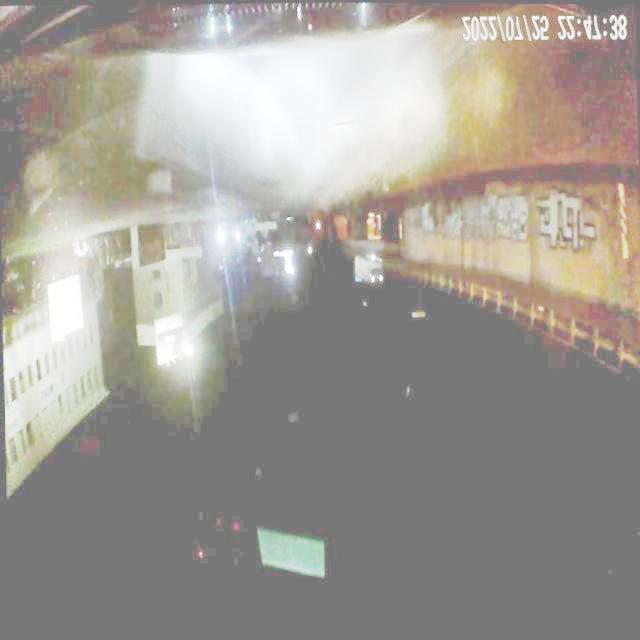

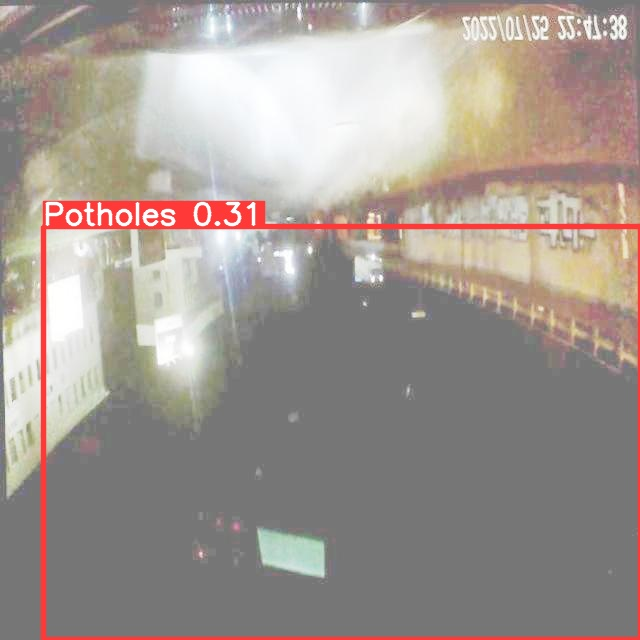

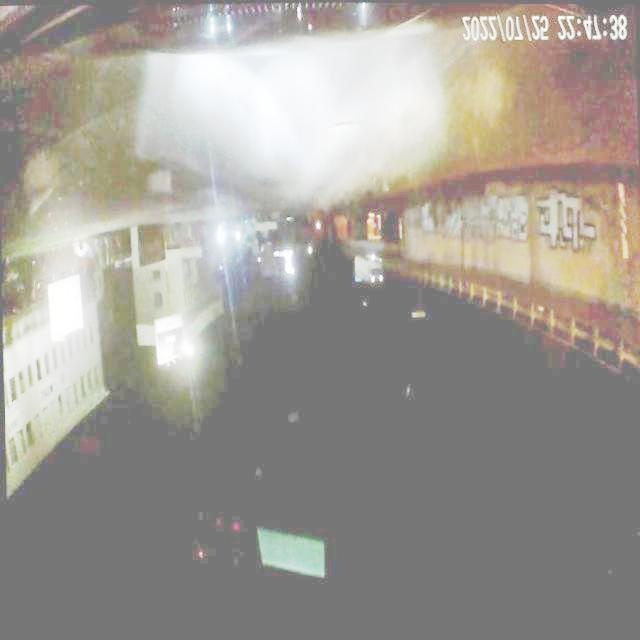

In [34]:
from pathlib import Path
from IPython.display import display
from PIL import Image

name = "Vid_Ca_night_00000064_jpg.rf.994882dde935bfc68361db69325b6094"

original = Path(
    "/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/test/images"
) / f"{name}.jpg"

baseline_pred = Path(
    "/kaggle/working/test_predictions/baseline"
) / f"{name}.jpg"

enhanced_pred = Path(
    "/kaggle/working/test_predictions/enhanced"
) / f"{name}.jpg"

print("Original:", original.exists())
print("Baseline:", baseline_pred.exists())
print("Enhanced:", enhanced_pred.exists())

display(Image.open(original))
display(Image.open(baseline_pred))
display(Image.open(enhanced_pred))

In [35]:
from pathlib import Path

name = "Vid_Ca_night_00000064_jpg.rf.994882dde935bfc68361db69325b6094"

label = Path(
    "/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/test/labels"
) / f"{name}.txt"

print("Ground-truth label exists:", label.exists())

if label.exists():
    print("\nGround-truth annotation:")
    print(label.read_text())

Ground-truth label exists: True

Ground-truth annotation:
0 0.54296875 0.2 0.06328125 0.05546875


In [36]:
from pathlib import Path

name = "Vid_Ca_night_00000064_jpg.rf.994882dde935bfc68361db69325b6094"

for model in ["baseline", "enhanced"]:
    label = Path(
        f"/kaggle/working/test_predictions/{model}/labels/{name}.txt"
    )

    print(f"\n{model.upper()} prediction:")
    if label.exists():
        print(label.read_text())
    else:
        print("No prediction")


BASELINE prediction:
0 0.533594 0.675781 0.932813 0.645312 0.314678


ENHANCED prediction:
No prediction


In [37]:
# Check the available YOLOv9 test/evaluation scripts
%cd /kaggle/working/yolov9

!ls -lh test.py val.py 2>/dev/null

/kaggle/working/yolov9
-rw-r--r-- 1 root root 20K Oct  7 03:20 val.py


In [38]:
%cd /kaggle/working/yolov9

!python val.py \
    --weights /kaggle/input/datasets/sanjanathanabalan/yolov9-mwpd-baseline-checkpoint/last.pt \
    --data /kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/data.yaml \
    --img 640 \
    --batch-size 4 \
    --conf-thres 0.001 \
    --iou-thres 0.6 \
    --device 0 \
    --task test \
    --name MWPD_baseline_test \
    --project /kaggle/working/test_evaluation \
    --exist-ok

/kaggle/working/yolov9
/kaggle/working/yolov9/utils/general.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg
val: data=/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/data.yaml, weights=['/kaggle/input/datasets/sanjanathanabalan/yolov9-mwpd-baseline-checkpoint/last.pt'], batch_size=4, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=test, device=0, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=/kaggle/working/test_evaluation, name=MWPD_baseline_test, exist_ok=True, half=False, dnn=False, min_items=0
YOLO 🚀 v0.1-104-g5b1ea9a Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)

Fusing layers... 
Model summary: 604 layers, 50698278 p

In [39]:
%%writefile /kaggle/working/yolov9/data_mwpd_test.yaml
test: /kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/test/images

nc: 1
names: ['Potholes']

Writing /kaggle/working/yolov9/data_mwpd_test.yaml


In [40]:
%cd /kaggle/working/yolov9

!python val.py \
    --weights /kaggle/input/datasets/sanjanathanabalan/yolov9-mwpd-baseline-checkpoint/last.pt \
    --data /kaggle/working/yolov9/data_mwpd_test.yaml \
    --img 640 \
    --batch-size 4 \
    --conf-thres 0.001 \
    --iou-thres 0.6 \
    --device 0 \
    --task test \
    --name MWPD_baseline_test \
    --project /kaggle/working/test_evaluation \
    --exist-ok

/kaggle/working/yolov9
/kaggle/working/yolov9/utils/general.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg
val: data=/kaggle/working/yolov9/data_mwpd_test.yaml, weights=['/kaggle/input/datasets/sanjanathanabalan/yolov9-mwpd-baseline-checkpoint/last.pt'], batch_size=4, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=test, device=0, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=/kaggle/working/test_evaluation, name=MWPD_baseline_test, exist_ok=True, half=False, dnn=False, min_items=0
YOLO 🚀 v0.1-104-g5b1ea9a Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)

Fusing layers... 
Model summary: 604 layers, 50698278 parameters, 0 gradients
Traceback (

In [41]:
%%writefile /kaggle/working/yolov9/data_mwpd_test.yaml
train: /kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/train/images
val: /kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/valid/images
test: /kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/test/images

nc: 1
names: ['Potholes']

Overwriting /kaggle/working/yolov9/data_mwpd_test.yaml


In [42]:
%cd /kaggle/working/yolov9

!python val.py \
    --weights /kaggle/input/datasets/sanjanathanabalan/yolov9-mwpd-baseline-checkpoint/last.pt \
    --data /kaggle/working/yolov9/data_mwpd_test.yaml \
    --img 640 \
    --batch-size 4 \
    --conf-thres 0.001 \
    --iou-thres 0.6 \
    --device 0 \
    --task test \
    --name MWPD_baseline_test \
    --project /kaggle/working/test_evaluation \
    --exist-ok

/kaggle/working/yolov9
/kaggle/working/yolov9/utils/general.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources as pkg
val: data=/kaggle/working/yolov9/data_mwpd_test.yaml, weights=['/kaggle/input/datasets/sanjanathanabalan/yolov9-mwpd-baseline-checkpoint/last.pt'], batch_size=4, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=test, device=0, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=/kaggle/working/test_evaluation, name=MWPD_baseline_test, exist_ok=True, half=False, dnn=False, min_items=0
YOLO 🚀 v0.1-104-g5b1ea9a Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14912MiB)

Fusing layers... 
Model summary: 604 layers, 50698278 parameters, 0 gradients
test: Scann

In [43]:
from pathlib import Path

pred_dir = Path("/kaggle/working/test_predictions/baseline/labels")

files = sorted(pred_dir.glob("*.txt"))

print("Prediction files:", len(files))

if files:
    print("\nExample file:", files[0].name)
    print(files[0].read_text())

Prediction files: 96

Example file: 12_jpg.rf.f29d25e2666191167fc39235f383bc53.txt
0 0.517969 0.754687 0.960938 0.465625 0.857937



In [44]:
import numpy as np
from pathlib import Path

GT_DIR = Path(
    "/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/test/labels"
)
PRED_DIR = Path(
    "/kaggle/working/test_predictions/baseline/labels"
)

def load_yolo_file(path):
    if not path.exists() or path.read_text().strip() == "":
        return []
    
    rows = []
    for line in path.read_text().strip().splitlines():
        v = list(map(float, line.split()))
        rows.append(v)
    return rows

def xywh_to_xyxy(box):
    _, xc, yc, w, h = box[:5]
    return [
        xc - w / 2,
        yc - h / 2,
        xc + w / 2,
        yc + h / 2
    ]

def iou(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b

    ix1 = max(ax1, bx1)
    iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)

    iw = max(0, ix2 - ix1)
    ih = max(0, iy2 - iy1)
    inter = iw * ih

    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)

    union = area_a + area_b - inter

    return inter / union if union > 0 else 0


# Evaluate every test image
gt_files = sorted(GT_DIR.glob("*.txt"))

predictions = []

for gt_file in gt_files:
    stem = gt_file.stem
    pred_file = PRED_DIR / f"{stem}.txt"

    gts = load_yolo_file(gt_file)
    preds = load_yolo_file(pred_file)

    for pred in preds:
        predictions.append({
            "image": stem,
            "box": xywh_to_xyxy(pred),
            "confidence": pred[5]
        })

# Sort all predictions by confidence
predictions.sort(key=lambda x: x["confidence"], reverse=True)

matched = set()
tp = []
fp = []

for pred in predictions:
    gt = load_yolo_file(GT_DIR / f"{pred['image']}.txt")
    gt_boxes = [xywh_to_xyxy(x) for x in gt]

    best_iou = 0
    best_idx = -1

    for idx, gt_box in enumerate(gt_boxes):
        if (pred["image"], idx) in matched:
            continue

        score = iou(pred["box"], gt_box)

        if score > best_iou:
            best_iou = score
            best_idx = idx

    if best_iou >= 0.50:
        matched.add((pred["image"], best_idx))
        tp.append(1)
        fp.append(0)
    else:
        tp.append(0)
        fp.append(1)

tp = np.array(tp)
fp = np.array(fp)

total_gt = sum(len(load_yolo_file(f)) for f in gt_files)

cum_tp = np.cumsum(tp)
cum_fp = np.cumsum(fp)

precision_curve = cum_tp / np.maximum(cum_tp + cum_fp, 1)
recall_curve = cum_tp / total_gt

precision = cum_tp[-1] / max(cum_tp[-1] + cum_fp[-1], 1)
recall = cum_tp[-1] / total_gt

# 11-point interpolated AP
ap = 0.0

for r in np.linspace(0, 1, 11):
    p = precision_curve[recall_curve >= r]
    ap += np.max(p) if len(p) else 0

ap /= 11

print("========== BASELINE TEST RESULTS ==========")
print("Test images :", len(gt_files))
print("Ground-truth objects :", total_gt)
print("Predictions :", len(predictions))
print(f"Precision @ IoU 0.50 : {precision:.4f}")
print(f"Recall @ IoU 0.50    : {recall:.4f}")
print(f"AP @ IoU 0.50        : {ap:.4f}")

========== BASELINE TEST RESULTS ==========
Test images : 97
Ground-truth objects : 292
Predictions : 308
Precision @ IoU 0.50 : 0.7403
Recall @ IoU 0.50    : 0.7808
AP @ IoU 0.50        : 0.6841


In [48]:
import numpy as np
from pathlib import Path

GT_DIR = Path(
    "/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/test/labels"
)

# CHANGED: enhanced predictions
PRED_DIR = Path(
    "/kaggle/working/test_predictions/enhanced/labels"
)


def load_yolo_file(path):
    if not path.exists() or path.read_text().strip() == "":
        return []

    rows = []
    for line in path.read_text().strip().splitlines():
        v = list(map(float, line.split()))
        rows.append(v)

    return rows


def xywh_to_xyxy(box):
    _, xc, yc, w, h = box[:5]

    return [
        xc - w / 2,
        yc - h / 2,
        xc + w / 2,
        yc + h / 2
    ]


def iou(a, b):
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b

    ix1 = max(ax1, bx1)
    iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)

    iw = max(0, ix2 - ix1)
    ih = max(0, iy2 - iy1)

    inter = iw * ih

    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)

    union = area_a + area_b - inter

    return inter / union if union > 0 else 0


# Evaluate every test image
gt_files = sorted(GT_DIR.glob("*.txt"))

predictions = []

for gt_file in gt_files:

    stem = gt_file.stem
    pred_file = PRED_DIR / f"{stem}.txt"

    gts = load_yolo_file(gt_file)
    preds = load_yolo_file(pred_file)

    for pred in preds:

        predictions.append({
            "image": stem,
            "box": xywh_to_xyxy(pred),
            "confidence": pred[5]
        })


# Sort predictions by confidence
predictions.sort(
    key=lambda x: x["confidence"],
    reverse=True
)

matched = set()

tp = []
fp = []


for pred in predictions:

    gt_file = GT_DIR / f"{pred['image']}.txt"

    gt = load_yolo_file(gt_file)

    gt_boxes = [
        xywh_to_xyxy(x)
        for x in gt
    ]

    best_iou = 0
    best_idx = -1

    for idx, gt_box in enumerate(gt_boxes):

        if (pred["image"], idx) in matched:
            continue

        score = iou(
            pred["box"],
            gt_box
        )

        if score > best_iou:

            best_iou = score
            best_idx = idx


    if best_iou >= 0.50:

        matched.add(
            (pred["image"], best_idx)
        )

        tp.append(1)
        fp.append(0)

    else:

        tp.append(0)
        fp.append(1)


tp = np.array(tp)
fp = np.array(fp)

total_gt = sum(
    len(load_yolo_file(f))
    for f in gt_files
)

cum_tp = np.cumsum(tp)
cum_fp = np.cumsum(fp)

precision_curve = (
    cum_tp /
    np.maximum(cum_tp + cum_fp, 1)
)

recall_curve = (
    cum_tp /
    total_gt
)


precision = (
    cum_tp[-1] /
    max(cum_tp[-1] + cum_fp[-1], 1)
)

recall = (
    cum_tp[-1] /
    total_gt
)


# 11-point interpolated AP
ap = 0.0

for r in np.linspace(0, 1, 11):

    p = precision_curve[
        recall_curve >= r
    ]

    if len(p):

        ap += np.max(p)


ap /= 11


print("========== ENHANCED TEST RESULTS ==========")
print("Test images :", len(gt_files))
print("Ground-truth objects :", total_gt)
print("Predictions :", len(predictions))
print(f"Precision @ IoU 0.50 : {precision:.4f}")
print(f"Recall @ IoU 0.50    : {recall:.4f}")
print(f"AP @ IoU 0.50        : {ap:.4f}")

========== ENHANCED TEST RESULTS ==========
Test images : 97
Ground-truth objects : 292
Predictions : 292
Precision @ IoU 0.50 : 0.7637
Recall @ IoU 0.50    : 0.7637
AP @ IoU 0.50        : 0.6808


In [49]:
from pathlib import Path

baseline_dir = Path("/kaggle/working/test_predictions/baseline/labels")
enhanced_dir = Path("/kaggle/working/test_predictions/enhanced/labels")

common = sorted(
    p.stem
    for p in baseline_dir.glob("*.txt")
    if (enhanced_dir / p.name).exists()
)

print("Images detected by both models:", len(common))

# Show the first 10 common prediction files
for name in common[:10]:
    print(name)

Images detected by both models: 95
12_jpg.rf.f29d25e2666191167fc39235f383bc53
139_jpg.rf.c76930d334d489e0a0ed49f8fa84157e
147_jpg.rf.9790d63eff52079b72c0b5512a8936c5
15_jpg.rf.8a3b6a68e19c6613d42d84771fcbbd65
181_jpg.rf.4165f90c4a4f60657dc050365b989e12
19_jpg.rf.02abab68b32c4f4b4b7da21eed9a9a16
200_jpg.rf.3e1e8a8801536a42a2fdf3b496e9f941
20240621_212348_jpg.rf.3770803e89dc7643273ed79de518ba17
213_jpg.rf.d820f640b1437d681a4ccafda8357d96
241_jpg.rf.02476041fda47f2867ae99450c8cb3f7


GROUND TRUTH:
0 0.43828125 0.7390625 0.80546875 0.4375

BASELINE PREDICTION:
0 0.517969 0.754687 0.960938 0.465625 0.857937


ENHANCED PREDICTION:
0 0.529688 0.736719 0.940625 0.489062 0.867169


--- ORIGINAL ---


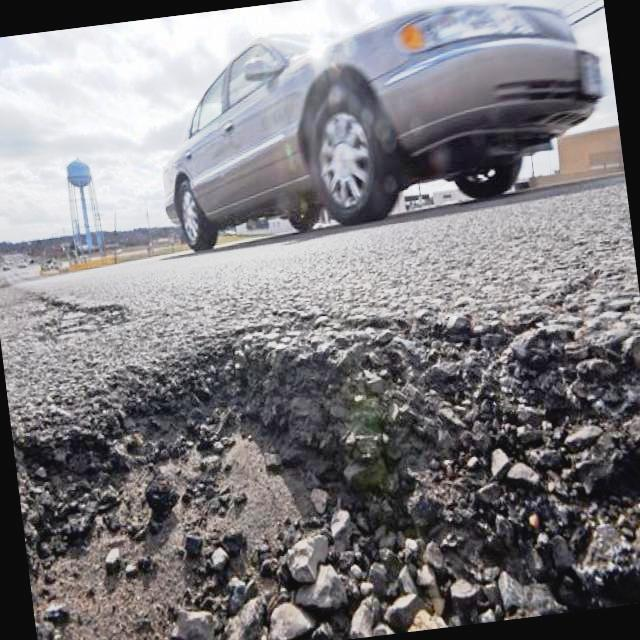


--- BASELINE ---


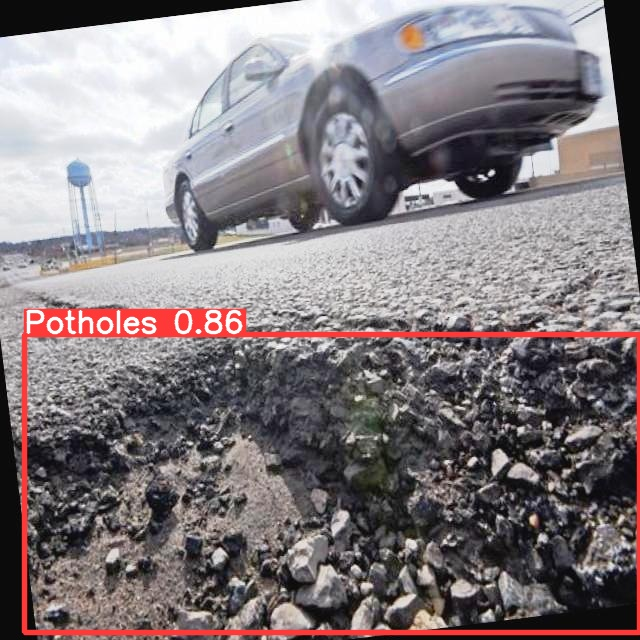


--- ENHANCED ---


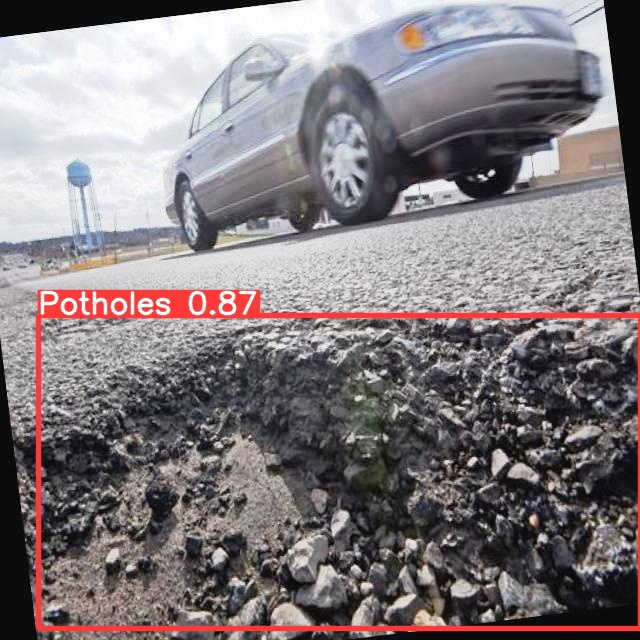

In [50]:
from pathlib import Path
from IPython.display import display
from PIL import Image

name = "12_jpg.rf.f29d25e2666191167fc39235f383bc53"

img = Path(
    "/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/test/images"
) / f"{name}.jpg"

gt = Path(
    "/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/test/labels"
) / f"{name}.txt"

baseline = Path(
    "/kaggle/working/test_predictions/baseline"
) / f"{name}.jpg"

enhanced = Path(
    "/kaggle/working/test_predictions/enhanced"
) / f"{name}.jpg"

print("GROUND TRUTH:")
print(gt.read_text())

print("\nBASELINE PREDICTION:")
print(
    (Path("/kaggle/working/test_predictions/baseline/labels") /
     f"{name}.txt").read_text()
)

print("\nENHANCED PREDICTION:")
print(
    (Path("/kaggle/working/test_predictions/enhanced/labels") /
     f"{name}.txt").read_text()
)

print("\n--- ORIGINAL ---")
display(Image.open(img))

print("\n--- BASELINE ---")
display(Image.open(baseline))

print("\n--- ENHANCED ---")
display(Image.open(enhanced))

In [51]:
from pathlib import Path

baseline_dir = Path("/kaggle/working/test_predictions/baseline/labels")
enhanced_dir = Path("/kaggle/working/test_predictions/enhanced/labels")

common = []

for bfile in baseline_dir.glob("*.txt"):
    efile = enhanced_dir / bfile.name

    if not efile.exists():
        continue

    b_lines = bfile.read_text().strip().splitlines()
    e_lines = efile.read_text().strip().splitlines()

    if not b_lines or not e_lines:
        continue

    b_conf = max(float(x.split()[5]) for x in b_lines)
    e_conf = max(float(x.split()[5]) for x in e_lines)

    common.append((b_conf + e_conf, b_conf, e_conf, bfile.stem))

common.sort(reverse=True)

print("Top 10 images where BOTH models have high-confidence detections:\n")

for score, b, e, name in common[:10]:
    print(
        f"{name} | "
        f"Baseline={b:.3f} | "
        f"Enhanced={e:.3f}"
    )

Top 10 images where BOTH models have high-confidence detections:

img-483_jpg.rf.71c0323101e91ed292fc6d57716b8367 | Baseline=0.935 | Enhanced=0.915
99_jpg.rf.9f86862c2cc573c17f6dae1f1faaa202 | Baseline=0.946 | Enhanced=0.895
29_jpg.rf.7763cca9be3120c26a65530fed868a17 | Baseline=0.912 | Enhanced=0.909
img-484_jpg.rf.a429272ae7c115a5d793f91b16d42cd6 | Baseline=0.931 | Enhanced=0.883
249_jpg.rf.8845d59aa80760bc0a07498e8abd32c0 | Baseline=0.929 | Enhanced=0.884
459_jpg.rf.b0872b0bf438a21000e6b7848adec74c | Baseline=0.920 | Enhanced=0.892
261_jpg.rf.cd4a2e948b582441b5dfe65a759f4eb6 | Baseline=0.933 | Enhanced=0.877
440_jpg.rf.8d67ca1da75c6c83166aaa7509069837 | Baseline=0.923 | Enhanced=0.885
90_jpg.rf.6585e0f85354bfd6cf3f10ebe4849023 | Baseline=0.892 | Enhanced=0.909
264_jpg.rf.1c0050524e62e77f0e82643b1d691f43 | Baseline=0.907 | Enhanced=0.888


GROUND TRUTH:
0 0.47734375 0.496875 0.64296875 0.74921875

BASELINE:
0 0.474219 0.514063 0.610937 0.759375 0.934505


ENHANCED:
0 0.475781 0.516406 0.626562 0.779688 0.914785


--- ORIGINAL IMAGE ---


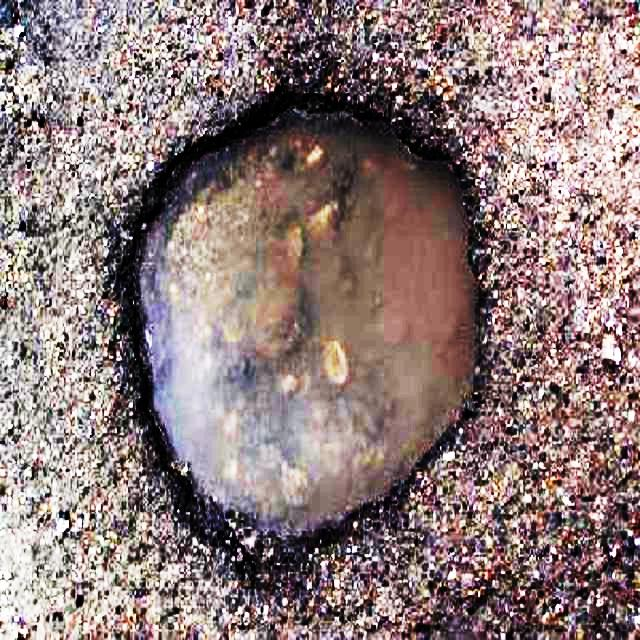


--- BASELINE ---


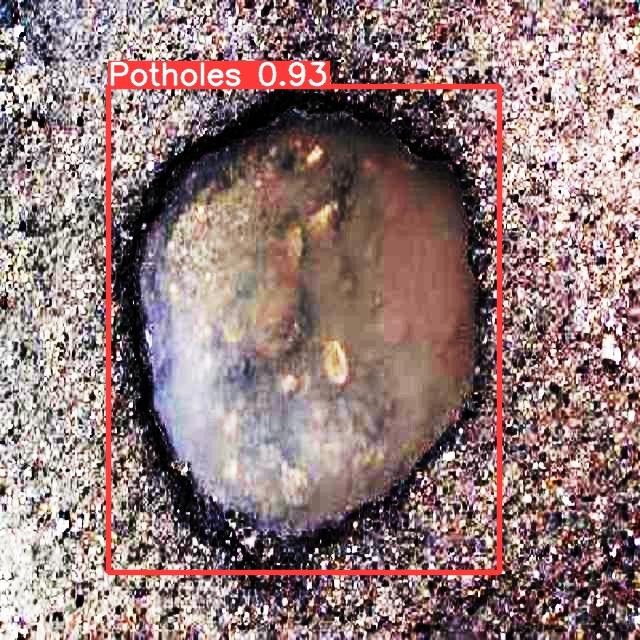


--- ENHANCED ---


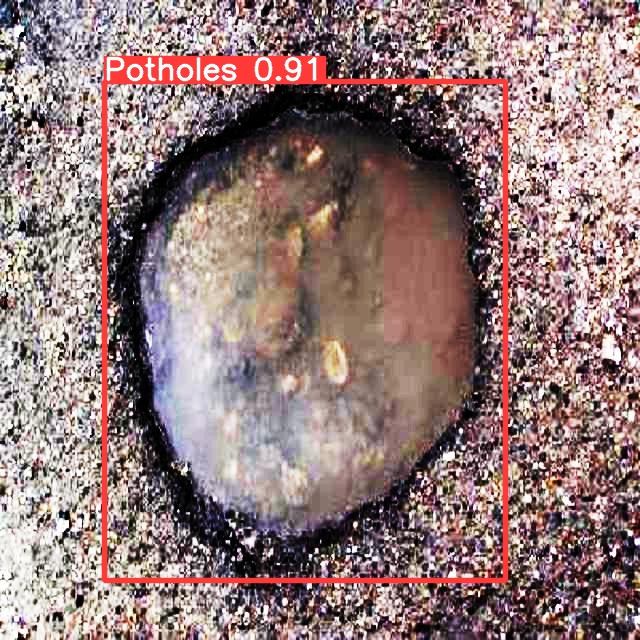

In [52]:
from pathlib import Path
from IPython.display import display
from PIL import Image

name = "img-483_jpg.rf.71c0323101e91ed292fc6d57716b8367"

base = "/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD"

print("GROUND TRUTH:")
print((Path(base) / "test/labels" / f"{name}.txt").read_text())

print("\nBASELINE:")
print((Path("/kaggle/working/test_predictions/baseline/labels") /
       f"{name}.txt").read_text())

print("\nENHANCED:")
print((Path("/kaggle/working/test_predictions/enhanced/labels") /
       f"{name}.txt").read_text())

print("\n--- ORIGINAL IMAGE ---")
display(Image.open(Path(base) / "test/images" / f"{name}.jpg"))

print("\n--- BASELINE ---")
display(Image.open(
    Path("/kaggle/working/test_predictions/baseline") / f"{name}.jpg"
))

print("\n--- ENHANCED ---")
display(Image.open(
    Path("/kaggle/working/test_predictions/enhanced") / f"{name}.jpg"
))

In [53]:
from pathlib import Path

baseline_dir = Path("/kaggle/working/test_predictions/baseline/labels")
enhanced_dir = Path("/kaggle/working/test_predictions/enhanced/labels")

candidates = []

for bfile in baseline_dir.glob("*.txt"):
    efile = enhanced_dir / bfile.name

    if not efile.exists():
        continue

    b_lines = bfile.read_text().strip().splitlines()
    e_lines = efile.read_text().strip().splitlines()

    if not b_lines or not e_lines:
        continue

    b_conf = max(float(x.split()[5]) for x in b_lines)
    e_conf = max(float(x.split()[5]) for x in e_lines)

    candidates.append({
        "name": bfile.stem,
        "baseline": b_conf,
        "enhanced": e_conf,
        "difference": abs(b_conf - e_conf)
    })

# 1. Highest confidence from both
both_high = sorted(
    candidates,
    key=lambda x: (x["baseline"] + x["enhanced"]),
    reverse=True
)

# 2. Enhanced confidence advantage
enhanced_better = sorted(
    candidates,
    key=lambda x: x["enhanced"] - x["baseline"],
    reverse=True
)

# 3. Baseline confidence advantage
baseline_better = sorted(
    candidates,
    key=lambda x: x["baseline"] - x["enhanced"],
    reverse=True
)

print("=== 5 PPT CANDIDATES ===\n")

selected = []

for item in both_high:
    if item["name"] not in selected:
        selected.append(item["name"])
        print(
            f"{len(selected)}. {item['name']}\n"
            f"   Baseline : {item['baseline']:.3f}\n"
            f"   Enhanced : {item['enhanced']:.3f}\n"
        )

    if len(selected) == 2:
        break

for item in enhanced_better:
    if item["name"] not in selected:
        selected.append(item["name"])
        print(
            f"{len(selected)}. {item['name']}\n"
            f"   Baseline : {item['baseline']:.3f}\n"
            f"   Enhanced : {item['enhanced']:.3f}\n"
        )

    if len(selected) == 3:
        break

for item in baseline_better:
    if item["name"] not in selected:
        selected.append(item["name"])
        print(
            f"{len(selected)}. {item['name']}\n"
            f"   Baseline : {item['baseline']:.3f}\n"
            f"   Enhanced : {item['enhanced']:.3f}\n"
        )

    if len(selected) == 4:
        break

# Add one night/difficult candidate
for item in candidates:
    if "night" in item["name"].lower() and item["name"] not in selected:
        selected.append(item["name"])
        print(
            f"{len(selected)}. {item['name']}\n"
            f"   Baseline : {item['baseline']:.3f}\n"
            f"   Enhanced : {item['enhanced']:.3f}\n"
        )
        break

print("\nSelected:", selected)

=== 5 PPT CANDIDATES ===

1. img-483_jpg.rf.71c0323101e91ed292fc6d57716b8367
   Baseline : 0.935
   Enhanced : 0.915

2. 99_jpg.rf.9f86862c2cc573c17f6dae1f1faaa202
   Baseline : 0.946
   Enhanced : 0.895

3. n27_jpg.rf.e8445b69a99f7f18e123fa7f0b981747
   Baseline : 0.253
   Enhanced : 0.496

4. img-75_jpg.rf.c6a0bd32b1abecd991c8a1814db9ac9d
   Baseline : 0.789
   Enhanced : 0.412


Selected: ['img-483_jpg.rf.71c0323101e91ed292fc6d57716b8367', '99_jpg.rf.9f86862c2cc573c17f6dae1f1faaa202', 'n27_jpg.rf.e8445b69a99f7f18e123fa7f0b981747', 'img-75_jpg.rf.c6a0bd32b1abecd991c8a1814db9ac9d']


In [54]:
from pathlib import Path

base = Path(
    "/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD"
)

names = [
    "img-483_jpg.rf.71c0323101e91ed292fc6d57716b8367",
    "99_jpg.rf.9f86862c2cc573c17f6dae1f1faaa202",
    "n27_jpg.rf.e8445b69a99f7f18e123fa7f0b981747",
    "img-75_jpg.rf.c6a0bd32b1abecd991c8a1814db9ac9d",
]

for name in names:
    print("\n" + "=" * 80)
    print(name)

    gt = base / "test/labels" / f"{name}.txt"
    b = Path("/kaggle/working/test_predictions/baseline/labels") / f"{name}.txt"
    e = Path("/kaggle/working/test_predictions/enhanced/labels") / f"{name}.txt"

    print("\nGROUND TRUTH:")
    print(gt.read_text() if gt.exists() else "No annotation")

    print("\nBASELINE:")
    print(b.read_text() if b.exists() else "No prediction")

    print("\nENHANCED:")
    print(e.read_text() if e.exists() else "No prediction")


img-483_jpg.rf.71c0323101e91ed292fc6d57716b8367

GROUND TRUTH:
0 0.47734375 0.496875 0.64296875 0.74921875

BASELINE:
0 0.474219 0.514063 0.610937 0.759375 0.934505


ENHANCED:
0 0.475781 0.516406 0.626562 0.779688 0.914785


99_jpg.rf.9f86862c2cc573c17f6dae1f1faaa202

GROUND TRUTH:
0 0.40703125 0.65703125 0.50546875 0.45234375
0 0.90234375 0.56875 0.1953125 0.34375

BASELINE:
0 0.896875 0.597656 0.20625 0.401563 0.852281
0 0.414844 0.644531 0.467187 0.529688 0.945514


ENHANCED:
0 0.9 0.598437 0.2 0.390625 0.857965
0 0.417188 0.650781 0.490625 0.517187 0.894801


n27_jpg.rf.e8445b69a99f7f18e123fa7f0b981747

GROUND TRUTH:
0 0.3875 0.51875 0.275 0.16640625
0 0.11328125 0.61328125 0.1171875 0.16640625

BASELINE:
0 0.40625 0.511719 0.315625 0.179688 0.253294


ENHANCED:
0 0.432813 0.500781 0.365625 0.195312 0.496489


img-75_jpg.rf.c6a0bd32b1abecd991c8a1814db9ac9d

GROUND TRUTH:
0 0.503125 0.475 0.13203125 0.11015625

BASELINE:
0 0.510156 0.483594 0.135937 0.114063 0.788818


ENHANCED:
0

In [55]:
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont

base = Path(
    "/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD"
)

baseline_dir = Path("/kaggle/working/test_predictions/baseline")
enhanced_dir = Path("/kaggle/working/test_predictions/enhanced")

output_dir = Path("/kaggle/working/PPT_qualitative_images")
output_dir.mkdir(exist_ok=True)

names = [
    "img-483_jpg.rf.71c0323101e91ed292fc6d57716b8367",
    "99_jpg.rf.9f86862c2cc573c17f6dae1f1faaa202",
    "img-75_jpg.rf.c6a0bd32b1abecd991c8a1814db9ac9d",
    "n27_jpg.rf.e8445b69a99f7f18e123fa7f0b981747",
]

labels = [
    "Both Models - Accurate Detection",
    "Multiple Pothole Detection",
    "Small Pothole Detection",
    "Challenging Case",
]

def resize_keep_ratio(img, width):
    ratio = width / img.width
    return img.resize((width, int(img.height * ratio)))

for name, title in zip(names, labels):

    original = Image.open(
        base / "test/images" / f"{name}.jpg"
    ).convert("RGB")

    baseline = Image.open(
        baseline_dir / f"{name}.jpg"
    ).convert("RGB")

    enhanced = Image.open(
        enhanced_dir / f"{name}.jpg"
    ).convert("RGB")

    # Same display width
    width = 500

    original = resize_keep_ratio(original, width)
    baseline = resize_keep_ratio(baseline, width)
    enhanced = resize_keep_ratio(enhanced, width)

    height = max(
        original.height,
        baseline.height,
        enhanced.height
    )

    # Canvas
    canvas = Image.new(
        "RGB",
        (width * 3, height + 70),
        "white"
    )

    # Paste images
    canvas.paste(original, (0, 70))
    canvas.paste(baseline, (width, 70))
    canvas.paste(enhanced, (width * 2, 70))

    draw = ImageDraw.Draw(canvas)

    # Labels
    try:
        font = ImageFont.truetype(
            "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
            24
        )
    except:
        font = ImageFont.load_default()

    draw.text(
        (15, 20),
        "Original",
        fill="black",
        font=font
    )

    draw.text(
        (width + 15, 20),
        "Baseline YOLOv9",
        fill="black",
        font=font
    )

    draw.text(
        (width * 2 + 15, 20),
        "Enhanced YOLOv9",
        fill="black",
        font=font
    )

    # Save individual image
    output_file = output_dir / f"{name}_comparison.jpg"
    canvas.save(output_file, quality=95)

    print("Saved:", output_file)

print("\nAll qualitative images saved to:")
print(output_dir)

Saved: /kaggle/working/PPT_qualitative_images/img-483_jpg.rf.71c0323101e91ed292fc6d57716b8367_comparison.jpg
Saved: /kaggle/working/PPT_qualitative_images/99_jpg.rf.9f86862c2cc573c17f6dae1f1faaa202_comparison.jpg
Saved: /kaggle/working/PPT_qualitative_images/img-75_jpg.rf.c6a0bd32b1abecd991c8a1814db9ac9d_comparison.jpg
Saved: /kaggle/working/PPT_qualitative_images/n27_jpg.rf.e8445b69a99f7f18e123fa7f0b981747_comparison.jpg

All qualitative images saved to:
/kaggle/working/PPT_qualitative_images


In [56]:
from pathlib import Path

yolo_dir = Path("/kaggle/working/yolov9")

model2 = Path(
    "/kaggle/working/runs/MWPD_YOLOv9_Enhanced/weights/best.pt"
)

test_images = Path(
    "/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/test/images"
)

print("YOLOv9 repo:", yolo_dir.exists())
print("Model 2:", model2.exists())
print("Test images:", len(list(test_images.glob("*.jpg"))))

print("\nRequired files:")
print("common.py:", (yolo_dir / "models/common.py").exists())
print("experimental.py:", (yolo_dir / "models/experimental.py").exists())
print("detect_dual.py:", (yolo_dir / "detect_dual.py").exists())

YOLOv9 repo: True
Model 2: True
Test images: 97

Required files:
common.py: True
experimental.py: True
detect_dual.py: True


In [57]:
import sys
import torch

sys.path.insert(0, "/kaggle/working/yolov9")

from models.experimental import attempt_load

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

model2 = attempt_load(
    "/kaggle/working/runs/MWPD_YOLOv9_Enhanced/weights/best.pt",
    device=device
)

model2 = model2.to(device)
model2.eval()

print("Model loaded successfully")
print("Device:", device)
print("Number of top-level layers:", len(model2.module_list))

print("\nLast 20 layers:")
for i, layer in list(enumerate(model2.module_list))[-20:]:
    print(i, type(layer).__name__)

Fusing layers... 
Model summary: 589 layers, 56662054 parameters, 0 gradients


Model loaded successfully
Device: cuda:0


AttributeError: 'DetectionModel' object has no attribute 'module_list'

In [58]:
print("Model type:", type(model2))
print("\nModel attributes/modules:")

for name, module in model2.named_children():
    print(name, "->", type(module).__name__)

Model type: <class 'models.yolo.DetectionModel'>

Model attributes/modules:
model -> Sequential


In [59]:
print("\nNamed modules containing convolution layers:")

for name, module in model2.named_modules():
    if isinstance(module, torch.nn.Conv2d):
        print(name, "-> Conv2d",
              "in:", module.in_channels,
              "out:", module.out_channels,
              "kernel:", module.kernel_size,
              "stride:", module.stride)


Named modules containing convolution layers:
model.1.conv -> Conv2d in: 3 out: 64 kernel: (3, 3) stride: (2, 2)
model.2.conv -> Conv2d in: 64 out: 128 kernel: (3, 3) stride: (2, 2)
model.3.cv1.conv -> Conv2d in: 128 out: 128 kernel: (1, 1) stride: (1, 1)
model.3.cv2.0.cv1.conv -> Conv2d in: 64 out: 32 kernel: (1, 1) stride: (1, 1)
model.3.cv2.0.cv2.conv -> Conv2d in: 64 out: 32 kernel: (1, 1) stride: (1, 1)
model.3.cv2.0.cv3.conv -> Conv2d in: 64 out: 64 kernel: (1, 1) stride: (1, 1)
model.3.cv2.0.m.0.cv1.conv -> Conv2d in: 32 out: 32 kernel: (3, 3) stride: (1, 1)
model.3.cv2.0.m.0.cv2.conv -> Conv2d in: 32 out: 32 kernel: (3, 3) stride: (1, 1)
model.3.cv2.1.conv -> Conv2d in: 64 out: 64 kernel: (3, 3) stride: (1, 1)
model.3.cv3.0.cv1.conv -> Conv2d in: 64 out: 32 kernel: (1, 1) stride: (1, 1)
model.3.cv3.0.cv2.conv -> Conv2d in: 64 out: 32 kernel: (1, 1) stride: (1, 1)
model.3.cv3.0.cv3.conv -> Conv2d in: 64 out: 64 kernel: (1, 1) stride: (1, 1)
model.3.cv3.0.m.0.cv1.conv -> Conv2d i

In [60]:
# Show the final 15 top-level model layers
print("Final top-level layers:\n")

for name, module in model2.named_children():
    print(name, "->", type(module).__name__)

print("\nModel.37 structure:\n")
print(model2.model[37])

Final top-level layers:

model -> Sequential

Model.37 structure:

RepNCSPELAN4(
  (cv1): Conv(
    (conv): Conv2d(512, 512, kernel_size=(1, 1), stride=(1, 1))
    (act): SiLU(inplace=True)
  )
  (cv2): Sequential(
    (0): RepNCSP(
      (cv1): Conv(
        (conv): Conv2d(256, 128, kernel_size=(1, 1), stride=(1, 1))
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(256, 128, kernel_size=(1, 1), stride=(1, 1))
        (act): SiLU(inplace=True)
      )
      (cv3): Conv(
        (conv): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
        (act): SiLU(inplace=True)
      )
      (m): Sequential(
        (0): RepNBottleneck(
          (cv1): RepConvN(
            (act): SiLU(inplace=True)
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          )
          (cv2): Conv(
            (conv): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (act): SiLU(inplace=True)
          )
  

In [61]:
from PIL import Image
import torch
import numpy as np

# Pick one MWPD test image
img_path = next(test_images.glob("*.jpg"))

img = Image.open(img_path).convert("RGB")
img = img.resize((640, 640))

# HWC -> CHW -> batch
img_tensor = torch.from_numpy(
    np.array(img).transpose(2, 0, 1)
).float() / 255.0

img_tensor = img_tensor.unsqueeze(0).to(device)

print("Input shape:", img_tensor.shape)

# Hook model.37
feature_output = {}

def hook_fn(module, inputs, output):
    feature_output["output"] = output

hook = model2.model[37].register_forward_hook(hook_fn)

with torch.no_grad():
    _ = model2(img_tensor)

hook.remove()

output = feature_output["output"]

print("Model.37 output type:", type(output))

if isinstance(output, (list, tuple)):
    print("Number of outputs:", len(output))
    for i, x in enumerate(output):
        if torch.is_tensor(x):
            print(f"Output {i} shape:", x.shape)
else:
    print("Output shape:", output.shape)

Input shape: torch.Size([1, 3, 640, 640])
Model.37 output type: <class 'torch.Tensor'>
Output shape: torch.Size([1, 512, 20, 20])


In [62]:
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# --------------------------------------------------
# Select an MWPD test image
# --------------------------------------------------
img_path = next(test_images.glob("*.jpg"))

original = cv2.imread(str(img_path))
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

# Resize to YOLO input size
input_img = cv2.resize(original, (640, 640))

img_tensor = torch.from_numpy(
    input_img.transpose(2, 0, 1)
).float() / 255.0

img_tensor = img_tensor.unsqueeze(0).to(device)
img_tensor.requires_grad_(True)

# --------------------------------------------------
# Grad-CAM storage
# --------------------------------------------------
activations = {}
gradients = {}

def forward_hook(module, inputs, output):
    activations["value"] = output

def backward_hook(module, grad_input, grad_output):
    gradients["value"] = grad_output[0]

target_layer = model2.model[37]

forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)

# --------------------------------------------------
# Forward pass
# --------------------------------------------------
model2.zero_grad(set_to_none=True)

output = model2(img_tensor)

print("Forward pass completed.")
print("Output type:", type(output))

# --------------------------------------------------
# Inspect output structure
# --------------------------------------------------
if isinstance(output, (list, tuple)):
    print("Number of outputs:", len(output))

    for i, item in enumerate(output):
        if torch.is_tensor(item):
            print(f"Output {i}: {item.shape}")
        else:
            print(f"Output {i}: {type(item)}")
else:
    print("Output shape:", output.shape)

# Remove hooks for now
forward_handle.remove()
backward_handle.remove()

Forward pass completed.
Output type: <class 'tuple'>
Number of outputs: 2
Output 0: <class 'list'>
Output 1: <class 'list'>


In [63]:
print("========== OUTPUT[0] ==========")

for i, item in enumerate(output[0]):
    print(
        f"[0][{i}] "
        f"type={type(item)}",
        f"shape={item.shape if torch.is_tensor(item) else 'N/A'}"
    )

print("\n========== OUTPUT[1] ==========")

for i, item in enumerate(output[1]):
    print(
        f"[1][{i}] "
        f"type={type(item)}",
        f"shape={item.shape if torch.is_tensor(item) else 'N/A'}"
    )

========== OUTPUT[0] ==========
[0][0] type=<class 'torch.Tensor'> shape=torch.Size([1, 5, 8400])
[0][1] type=<class 'torch.Tensor'> shape=torch.Size([1, 5, 8400])

========== OUTPUT[1] ==========
[1][0] type=<class 'list'> shape=N/A
[1][1] type=<class 'list'> shape=N/A


In [64]:
pred = output[0][0]

print("Prediction shape:", pred.shape)

print("\nFirst 5 predictions:")
print(pred[0, :, :5])

print("\nChannel statistics:")
for c in range(pred.shape[1]):
    channel = pred[0, c]
    print(
        f"Channel {c}: "
        f"min={channel.min().item():.4f}, "
        f"max={channel.max().item():.4f}, "
        f"mean={channel.mean().item():.4f}"
    )

Prediction shape: torch.Size([1, 5, 8400])

First 5 predictions:
tensor([[7.57677e+00, 1.35627e+01, 4.25336e+01, 5.37676e+01, 5.26004e+01],
        [1.67078e+01, 2.56394e+01, 1.80874e+01, 1.09190e+01, 1.03854e+01],
        [1.77609e+01, 2.90583e+01, 8.85033e+01, 5.90454e+01, 5.37676e+01],
        [6.28069e+01, 6.54770e+01, 4.08259e+01, 2.15019e+01, 2.00998e+01],
        [6.43171e-06, 5.37058e-06, 8.13635e-06, 1.09729e-04, 2.20248e-04]], device='cuda:0', grad_fn=<SliceBackward0>)

Channel statistics:
Channel 0: min=4.9247, max=635.4517, mean=320.0666
Channel 1: min=4.3406, max=636.2609, mean=320.9403
Channel 2: min=6.0659, max=481.9713, mean=85.7482
Channel 3: min=7.0003, max=460.8789, mean=88.1763
Channel 4: min=0.0000, max=0.8711, mean=0.0010


In [65]:
# Detection tensor
pred = output[0][0]          # [1, 5, 8400]

# Pothole/object confidence
scores = pred[0, 4, :]       # [8400]

# Find strongest prediction
best_idx = torch.argmax(scores)
best_score = scores[best_idx]

print("Best prediction index:", best_idx.item())
print("Best pothole confidence:", best_score.item())

print("\nBest prediction:")
print("x =", pred[0, 0, best_idx].item())
print("y =", pred[0, 1, best_idx].item())
print("w =", pred[0, 2, best_idx].item())
print("h =", pred[0, 3, best_idx].item())
print("score =", best_score.item())

Best prediction index: 8249
Best pothole confidence: 0.871110737323761

Best prediction:
x = 319.23529052734375
y = 374.4407043457031
w = 349.01318359375
h = 253.53675842285156
score = 0.871110737323761


In [66]:
# ============================================
# MODEL 2 — Grad-CAM
# ============================================

import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Re-register hooks
activations = {}
gradients = {}

def forward_hook(module, inputs, output):
    activations["value"] = output

def backward_hook(module, grad_input, grad_output):
    gradients["value"] = grad_output[0]

target_layer = model2.model[37]

forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)

# Clear gradients
model2.zero_grad(set_to_none=True)

# Forward pass
output = model2(img_tensor)

# Get prediction tensor
pred = output[0][0]             # [1, 5, 8400]

# Select strongest pothole prediction
scores = pred[0, 4, :]
best_idx = torch.argmax(scores)

# IMPORTANT:
# Use the actual differentiable prediction score
target_score = pred[0, 4, best_idx]

print("Target prediction index:", best_idx.item())
print("Target confidence:", target_score.item())

# Backpropagate
target_score.backward()

# Retrieve feature map and gradients
feature_map = activations["value"]
gradient = gradients["value"]

print("\nFeature map shape:", feature_map.shape)
print("Gradient shape:", gradient.shape)

# ============================================
# Grad-CAM calculation
# ============================================

# Global average pooling over spatial dimensions
weights = gradient.mean(dim=(2, 3), keepdim=True)

# Weighted feature maps
cam = (weights * feature_map).sum(dim=1, keepdim=True)

# ReLU
cam = torch.relu(cam)

# Remove batch/channel dimensions
cam = cam.squeeze().detach().cpu().numpy()

# Normalize
cam -= cam.min()

if cam.max() > 0:
    cam /= cam.max()

# Resize CAM to image size
cam = cv2.resize(cam, (640, 640))

# ============================================
# Prepare visualization
# ============================================

heatmap = np.uint8(255 * cam)

heatmap_color = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)

heatmap_color = cv2.cvtColor(
    heatmap_color,
    cv2.COLOR_BGR2RGB
)

overlay = (
    0.5 * input_img.astype(np.float32)
    + 0.5 * heatmap_color.astype(np.float32)
)

overlay = np.clip(overlay, 0, 255).astype(np.uint8)

# ============================================
# Bounding box from prediction
# ============================================

x = pred[0, 0, best_idx].item()
y = pred[0, 1, best_idx].item()
w = pred[0, 2, best_idx].item()
h = pred[0, 3, best_idx].item()

x1 = int(max(0, x - w / 2))
y1 = int(max(0, y - h / 2))
x2 = int(min(640, x + w / 2))
y2 = int(min(640, y + h / 2))

# Draw bounding box
overlay_box = overlay.copy()

cv2.rectangle(
    overlay_box,
    (x1, y1),
    (x2, y2),
    (255, 255, 0),
    3
)

cv2.putText(
    overlay_box,
    f"Pothole {target_score.item():.2f}",
    (x1, max(25, y1 - 10)),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.7,
    (255, 255, 0),
    2
)

# Remove hooks
forward_handle.remove()
backward_handle.remove()

# ============================================
# Display
# ============================================

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.imshow(input_img)
plt.title("Model 2 - Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap_color)
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay_box)
plt.title("Model 2 - XAI Explanation")
plt.axis("off")

plt.tight_layout()
plt.show()

Target prediction index: 8249
Target confidence: 0.871110737323761

Feature map shape: torch.Size([1, 512, 20, 20])
Gradient shape: torch.Size([1, 512, 20, 20])


In [67]:
from pathlib import Path

xai_dir = Path("/kaggle/working/Model2_XAI")
xai_dir.mkdir(parents=True, exist_ok=True)

# Save the three XAI outputs
original_path = xai_dir / "original.jpg"
heatmap_path = xai_dir / "gradcam_heatmap.jpg"
overlay_path = xai_dir / "model2_gradcam_explanation.jpg"

cv2.imwrite(
    str(original_path),
    cv2.cvtColor(input_img, cv2.COLOR_RGB2BGR)
)

cv2.imwrite(
    str(heatmap_path),
    cv2.cvtColor(heatmap_color, cv2.COLOR_RGB2BGR)
)

cv2.imwrite(
    str(overlay_path),
    cv2.cvtColor(overlay_box, cv2.COLOR_RGB2BGR)
)

print("XAI results saved:")
print(original_path)
print(heatmap_path)
print(overlay_path)

XAI results saved:
/kaggle/working/Model2_XAI/original.jpg
/kaggle/working/Model2_XAI/gradcam_heatmap.jpg
/kaggle/working/Model2_XAI/model2_gradcam_explanation.jpg


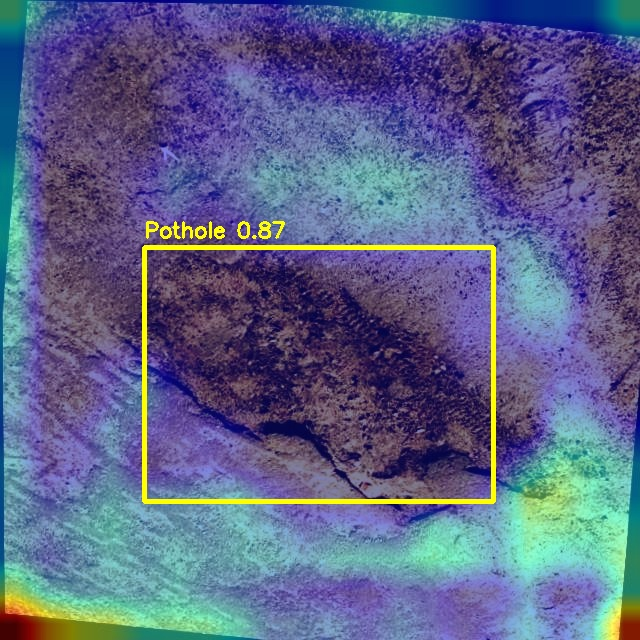

In [68]:
from IPython.display import display
from PIL import Image

display(Image.open("/kaggle/working/Model2_XAI/model2_gradcam_explanation.jpg"))

In [69]:
# ============================================
# MODEL 2 XAI — SECOND TEST IMAGE
# ============================================

from pathlib import Path
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

# Pick another test image
test_files = sorted(test_images.glob("*.jpg"))

# Change this index if needed
img_path = test_files[10]

print("Testing image:", img_path.name)

# Load image
original = cv2.imread(str(img_path))
original = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)

input_img = cv2.resize(original, (640, 640))

img_tensor = torch.from_numpy(
    input_img.transpose(2, 0, 1)
).float() / 255.0

img_tensor = img_tensor.unsqueeze(0).to(device)
img_tensor.requires_grad_(True)

# ============================================
# Hooks
# ============================================

activations = {}
gradients = {}

def forward_hook(module, inputs, output):
    activations["value"] = output

def backward_hook(module, grad_input, grad_output):
    gradients["value"] = grad_output[0]

target_layer = model2.model[37]

forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)

# ============================================
# Forward
# ============================================

model2.zero_grad(set_to_none=True)

output = model2(img_tensor)

pred = output[0][0]

# Highest-confidence prediction
scores = pred[0, 4, :]
best_idx = torch.argmax(scores)
target_score = pred[0, 4, best_idx]

print("Best confidence:", target_score.item())

# ============================================
# Backward
# ============================================

target_score.backward()

feature_map = activations["value"]
gradient = gradients["value"]

# Grad-CAM
weights = gradient.mean(dim=(2, 3), keepdim=True)

cam = (weights * feature_map).sum(dim=1, keepdim=True)
cam = torch.relu(cam)

cam = cam.squeeze().detach().cpu().numpy()

cam -= cam.min()

if cam.max() > 0:
    cam /= cam.max()

cam = cv2.resize(cam, (640, 640))

# ============================================
# Heatmap
# ============================================

heatmap = np.uint8(255 * cam)

heatmap_color = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)

heatmap_color = cv2.cvtColor(
    heatmap_color,
    cv2.COLOR_BGR2RGB
)

overlay = (
    0.5 * input_img.astype(np.float32)
    + 0.5 * heatmap_color.astype(np.float32)
)

overlay = np.clip(overlay, 0, 255).astype(np.uint8)

# ============================================
# Bounding box
# ============================================

x = pred[0, 0, best_idx].item()
y = pred[0, 1, best_idx].item()
w = pred[0, 2, best_idx].item()
h = pred[0, 3, best_idx].item()

x1 = int(max(0, x - w / 2))
y1 = int(max(0, y - h / 2))
x2 = int(min(640, x + w / 2))
y2 = int(min(640, y + h / 2))

cv2.rectangle(
    overlay,
    (x1, y1),
    (x2, y2),
    (255, 255, 0),
    3
)

cv2.putText(
    overlay,
    f"Pothole {target_score.item():.2f}",
    (x1, max(25, y1 - 10)),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.7,
    (255, 255, 0),
    2
)

forward_handle.remove()
backward_handle.remove()

# ============================================
# Display
# ============================================

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.imshow(input_img)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap_color)
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title("Model 2 XAI")
plt.axis("off")

plt.tight_layout()
plt.show()

Testing image: 249_jpg.rf.8845d59aa80760bc0a07498e8abd32c0.jpg
Best confidence: 0.9148120880126953


In [73]:
# Display the XAI result
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.imshow(input_img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap_color)
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(overlay)
plt.title(f"Model 2 XAI - {target_score.item():.2f}")
plt.axis("off")

plt.tight_layout()
plt.show()

In [74]:
print("input_img:", input_img.shape)
print("heatmap_color:", heatmap_color.shape)
print("overlay:", overlay.shape)
print("confidence:", target_score.item())

input_img: (640, 640, 3)
heatmap_color: (640, 640, 3)
overlay: (640, 640, 3)
confidence: 0.9148120880126953


In [77]:
from IPython.display import display
from PIL import Image
import matplotlib.pyplot as plt

plt.imshow(overlay)
plt.axis("off")
plt.title("Model 2 Grad-CAM XAI")
plt.show()

In [78]:
print("Overlay min:", overlay.min())
print("Overlay max:", overlay.max())
print("Overlay dtype:", overlay.dtype)

Overlay min: 0
Overlay max: 255
Overlay dtype: uint8


Saved: /kaggle/working/Model2_XAI/second_model2_xai.png
Size: (640, 640)


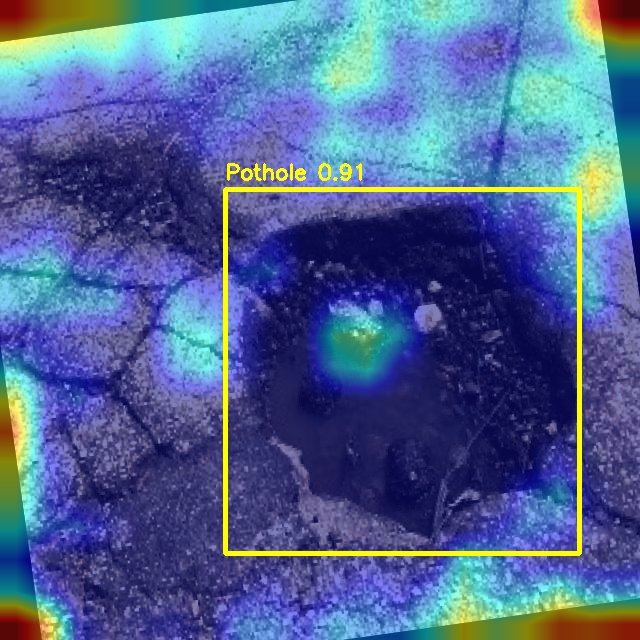

In [79]:
from PIL import Image
from IPython.display import display

save_path = "/kaggle/working/Model2_XAI/second_model2_xai.png"

Image.fromarray(overlay).save(save_path)

print("Saved:", save_path)
print("Size:", Image.open(save_path).size)

display(Image.open(save_path))

In [80]:
import torch
import transformers

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )

PyTorch: 2.11.0+cu128
Transformers: 5.16.1
CUDA available: True
GPU: Tesla T4
GPU memory: 14.56 GB


In [81]:
import transformers

print("Transformers version:", transformers.__version__)

try:
    from transformers import Qwen3VLForConditionalGeneration, AutoProcessor
    print("Qwen3-VL support: OK")
except ImportError as e:
    print("Qwen3-VL support not available:")
    print(e)

Transformers version: 5.16.1
Qwen3-VL support: OK


In [82]:
import torch
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor

vlm_name = "Qwen/Qwen3-VL-4B-Instruct"

print("Loading VLM...")

vlm_processor = AutoProcessor.from_pretrained(vlm_name)

vlm_model = Qwen3VLForConditionalGeneration.from_pretrained(
    vlm_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

vlm_model.eval()

print("VLM loaded successfully.")
print("Device:", next(vlm_model.parameters()).device)

Loading VLM...


preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/5.50k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.50k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/10.9k [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

VLM loaded successfully.
Device: cuda:0


In [83]:
from PIL import Image

# Same image used for our second XAI test
vlm_image_path = str(img_path)

image = Image.open(vlm_image_path).convert("RGB")

prompt = """
You are analyzing a road image for pothole detection.

Analyze the image carefully and provide a concise structured report with:

1. Detection: Is a pothole visible?
2. Visual description: Describe the pothole's shape, size, surface appearance, and surrounding road damage.
3. Severity: Estimate the visible severity as Low, Moderate, or High based only on visual evidence.
4. Safety risk: Explain the potential risk to vehicles or road users.
5. Reasoning: Explain which visible characteristics support your assessment.

Do not invent measurements or information that cannot be determined from the image.
"""

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": image},
            {"type": "text", "text": prompt},
        ],
    }
]

text = vlm_processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

inputs = vlm_processor(
    text=[text],
    images=[image],
    return_tensors="pt"
)

inputs = {
    k: v.to(vlm_model.device) if torch.is_tensor(v) else v
    for k, v in inputs.items()
}

with torch.no_grad():
    generated_ids = vlm_model.generate(
        **inputs,
        max_new_tokens=300,
        do_sample=False
    )

# Remove the input tokens from the generated sequence
generated_ids_trimmed = [
    out_ids[len(in_ids):]
    for in_ids, out_ids in zip(inputs["input_ids"], generated_ids)
]

response = vlm_processor.batch_decode(
    generated_ids_trimmed,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False
)[0]

print("========== VLM REPORT ==========\n")
print(response)

========== VLM REPORT ==========

1. Detection: Yes, a pothole is visible.

2. Visual description:
   - Shape: Irregular, roughly circular to oval, with jagged, broken edges.
   - Size: Moderate to large, occupying a significant portion of the frame, likely several inches to a foot in diameter.
   - Surface appearance: Deep, dark, and filled with water and debris (small stones, dirt, and possibly organic matter). The water surface reflects light, indicating a liquid-filled cavity.
   - Surrounding road damage: The asphalt around the pothole is severely cracked, with a network of fissures radiating outward. The surrounding pavement is broken and fragmented, indicating advanced deterioration.

3. Severity: High

4. Safety risk: High risk of vehicle damage (tire punctures, suspension damage, or loss of control) and potential for injury or fatality to road users (especially if a vehicle hits it at speed). The water and debris can cause hydroplaning or sudden loss of traction.

5. Reasoning

In [84]:
from pathlib import Path

# Find uploaded image files
for p in Path("/kaggle/input").rglob("*"):
    if p.is_file():
        print(p)

/kaggle/input/datasets/sanjanathanabalan/pothole1/pothole image .jpg
/kaggle/input/datasets/sanjanathanabalan/yolov9-mwpd-baseline-checkpoint/last.pt
/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/README.roboflow.txt
/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/data.yaml
/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/train/labels/n30_jpg.rf.b8bca6e630f1c2660e286b4dfdece8ef.txt
/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/train/labels/img-13_jpg.rf.b5fc9eade505530aca39097edc4a7ee0.txt
/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/train/labels/340_jpg.rf.52849e9e047bb43bd33638cc0fd29bd4.txt
/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/train/labels/img-2_jpg.rf.25ca5edcda8520bb0b268a53ab708950.txt
/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset/MWPD/train/labels/img-289_jpg.rf.3e46be6106f2abd4ea8625eb6491c7a2.txt
/kaggle/input/datasets/sanjanathanaba

KeyboardInterrupt: 

In [85]:
from pathlib import Path

pothole_input = Path("/kaggle/input/pothole1")

print("Exists:", pothole_input.exists())

if pothole_input.exists():
    print("Contents:")
    for p in pothole_input.iterdir():
        print(p)

Exists: False


In [86]:
from pathlib import Path

print("Kaggle inputs:")

for p in Path("/kaggle/input").iterdir():
    print(p)

Kaggle inputs:
/kaggle/input/datasets


In [87]:
from pathlib import Path

datasets_dir = Path("/kaggle/input/datasets")

for p in datasets_dir.iterdir():
    print(p)

/kaggle/input/datasets/sanjanathanabalan


In [88]:
from pathlib import Path

user_dir = Path("/kaggle/input/datasets/sanjanathanabalan")

for p in user_dir.iterdir():
    print(p)

/kaggle/input/datasets/sanjanathanabalan/pothole1
/kaggle/input/datasets/sanjanathanabalan/mwpd-pothole-dataset
/kaggle/input/datasets/sanjanathanabalan/yolov9-mwpd-baseline-checkpoint


In [89]:
from pathlib import Path

pothole_dir = Path("/kaggle/input/datasets/sanjanathanabalan/pothole1")

print("Contents:")
for p in pothole_dir.iterdir():
    print(p)

Contents:
/kaggle/input/datasets/sanjanathanabalan/pothole1/pothole image .jpg


In [90]:
import cv2
import torch
import matplotlib.pyplot as plt

new_img_path = "/kaggle/input/datasets/sanjanathanabalan/pothole1/pothole image .jpg"

# Load image
new_original = cv2.imread(new_img_path)
new_original = cv2.cvtColor(new_original, cv2.COLOR_BGR2RGB)

print("Original image shape:", new_original.shape)

# Resize for YOLOv9
new_input = cv2.resize(new_original, (640, 640))

new_tensor = torch.from_numpy(
    new_input.transpose(2, 0, 1)
).float() / 255.0

new_tensor = new_tensor.unsqueeze(0).to(device)

# Model 2 inference
model2.zero_grad(set_to_none=True)

with torch.no_grad():
    new_output = model2(new_tensor)

new_pred = new_output[0][0]

print("Prediction shape:", new_pred.shape)

# Get confidence scores
new_scores = new_pred[0, 4, :]

best_new_idx = torch.argmax(new_scores)
best_new_score = new_scores[best_new_idx].item()

print("Best detection confidence:", best_new_score)

# Bounding box
x = new_pred[0, 0, best_new_idx].item()
y = new_pred[0, 1, best_new_idx].item()
w = new_pred[0, 2, best_new_idx].item()
h = new_pred[0, 3, best_new_idx].item()

print("Bounding box:")
print("x:", x)
print("y:", y)
print("w:", w)
print("h:", h)

Original image shape: (1040, 1560, 3)
Prediction shape: torch.Size([1, 5, 8400])
Best detection confidence: 0.9048099517822266
Bounding box:
x: 339.0843200683594
y: 428.2030944824219
w: 416.21722412109375
h: 424.75250244140625


In [91]:
# ============================================
# XAI ON NEW UNSEEN IMAGE
# ============================================

activations = {}
gradients = {}

def forward_hook(module, inputs, output):
    activations["value"] = output

def backward_hook(module, grad_input, grad_output):
    gradients["value"] = grad_output[0]

target_layer = model2.model[37]

forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)

model2.zero_grad(set_to_none=True)

# Need gradients for XAI
new_tensor = new_tensor.detach().clone().requires_grad_(True)

new_output = model2(new_tensor)
new_pred = new_output[0][0]

# Select strongest pothole prediction
new_scores = new_pred[0, 4, :]
best_new_idx = torch.argmax(new_scores)

target_score = new_pred[0, 4, best_new_idx]

print("Target confidence:", target_score.item())

# Backpropagate
target_score.backward()

feature_map = activations["value"]
gradient = gradients["value"]

print("Feature map:", feature_map.shape)
print("Gradient:", gradient.shape)

# Grad-CAM
weights = gradient.mean(dim=(2, 3), keepdim=True)

cam = (weights * feature_map).sum(dim=1, keepdim=True)
cam = torch.relu(cam)

cam = cam.squeeze().detach().cpu().numpy()

cam -= cam.min()

if cam.max() > 0:
    cam /= cam.max()

cam = cv2.resize(cam, (640, 640))

# Heatmap
heatmap = np.uint8(255 * cam)

heatmap_color = cv2.applyColorMap(
    heatmap,
    cv2.COLORMAP_JET
)

heatmap_color = cv2.cvtColor(
    heatmap_color,
    cv2.COLOR_BGR2RGB
)

# Overlay
new_overlay = (
    0.5 * new_input.astype(np.float32)
    + 0.5 * heatmap_color.astype(np.float32)
)

new_overlay = np.clip(
    new_overlay, 0, 255
).astype(np.uint8)

# Bounding box
x = new_pred[0, 0, best_new_idx].item()
y = new_pred[0, 1, best_new_idx].item()
w = new_pred[0, 2, best_new_idx].item()
h = new_pred[0, 3, best_new_idx].item()

x1 = int(max(0, x - w / 2))
y1 = int(max(0, y - h / 2))
x2 = int(min(640, x + w / 2))
y2 = int(min(640, y + h / 2))

cv2.rectangle(
    new_overlay,
    (x1, y1),
    (x2, y2),
    (255, 255, 0),
    3
)

cv2.putText(
    new_overlay,
    f"Pothole {target_score.item():.2f}",
    (x1, max(25, y1 - 10)),
    cv2.FONT_HERSHEY_SIMPLEX,
    0.7,
    (255, 255, 0),
    2
)

forward_handle.remove()
backward_handle.remove()

# Display
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.imshow(new_input)
plt.title("New Unseen Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap_color)
plt.title("Model 2 Grad-CAM")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(new_overlay)
plt.title("Model 2 XAI")
plt.axis("off")

plt.tight_layout()
plt.show()

Target confidence: 0.9048099517822266
Feature map: torch.Size([1, 512, 20, 20])
Gradient: torch.Size([1, 512, 20, 20])


Saved: /kaggle/working/Model2_XAI/new_external_xai.png


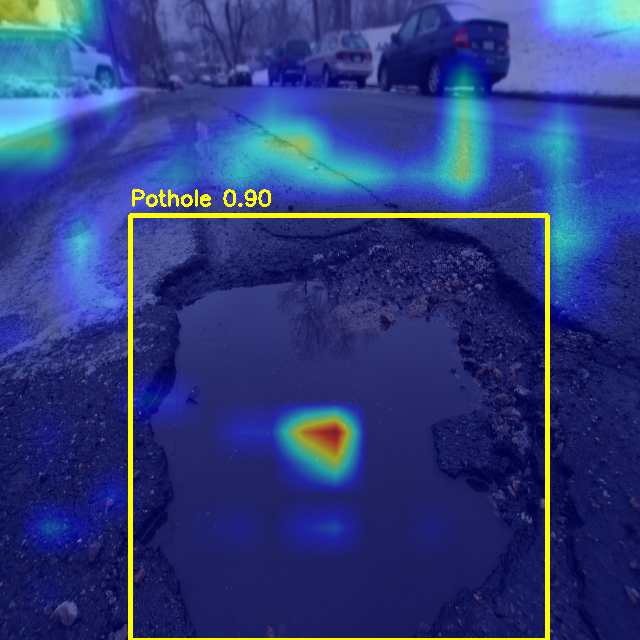

In [92]:
from PIL import Image
from IPython.display import display

new_xai_path = "/kaggle/working/Model2_XAI/new_external_xai.png"

Image.fromarray(new_overlay).save(new_xai_path)

print("Saved:", new_xai_path)

display(Image.open(new_xai_path))

In [93]:
from PIL import Image
import torch

# Completely new external image
new_vlm_image = Image.open(
    "/kaggle/input/datasets/sanjanathanabalan/pothole1/pothole image .jpg"
).convert("RGB")

prompt = """
Analyze this road image as a computer-vision assistant.

Provide a concise report with:

1. Detection: Is a pothole visible?
2. Visual description: Describe the visible pothole and surrounding road condition.
3. Severity: Classify the visually apparent severity as Low, Moderate, or High.
4. Safety risk: Describe the potential road-user risk based only on visible evidence.
5. Reasoning: Explain which visible characteristics support the assessment.

Important:
- Do not invent physical measurements.
- Do not claim an exact pothole depth or size without a reference scale.
- Clearly state that severity and risk are visual estimates.
"""

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": new_vlm_image},
            {"type": "text", "text": prompt},
        ],
    }
]

text = vlm_processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

inputs = vlm_processor(
    text=[text],
    images=[new_vlm_image],
    return_tensors="pt"
)

inputs = {
    k: v.to(vlm_model.device) if torch.is_tensor(v) else v
    for k, v in inputs.items()
}

with torch.no_grad():
    generated_ids = vlm_model.generate(
        **inputs,
        max_new_tokens=300,
        do_sample=False
    )

generated_ids_trimmed = [
    out_ids[len(in_ids):]
    for in_ids, out_ids in zip(
        inputs["input_ids"],
        generated_ids
    )
]

vlm_response = vlm_processor.batch_decode(
    generated_ids_trimmed,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False
)[0]

print("========== NEW IMAGE VLM REPORT ==========\n")
print(vlm_response)

========== NEW IMAGE VLM REPORT ==========

1. Detection: Yes, a pothole is visible.

2. Visual description: A large, irregularly shaped pothole is centered in the foreground, filled with dark water that reflects the surrounding trees and sky. The edges of the pothole are jagged and uneven, with loose asphalt, gravel, and small stones protruding around its perimeter. The surrounding road surface is cracked and worn, with patches of ice or frost visible along the curb and adjacent to the pothole. The road extends into the background, where several parked cars are visible under a snowy or icy landscape.

3. Severity: High

4. Safety risk: The pothole poses a significant risk of vehicle damage or loss of control for drivers, especially at higher speeds. It may cause a vehicle to dip or bounce, potentially leading to a skid, tire blowout, or damage to undercarriage components. Pedestrians may also be at risk of tripping or slipping on the uneven, icy surface.

5. Reasoning: The pothole is 

In [94]:
# Save VLM report
report_path = "/kaggle/working/Model2_XAI_VLM_Report.txt"

with open(report_path, "w", encoding="utf-8") as f:
    f.write("MODEL 2 — XAI + VLM REPORT\n")
    f.write("=" * 50 + "\n\n")

    f.write("Model: Enhanced YOLOv9 (Model 2)\n")
    f.write("Test image: pothole image .jpg\n")
    f.write("YOLOv9 confidence: 90.48%\n\n")

    f.write("VLM MODEL\n")
    f.write("-" * 50 + "\n")
    f.write("Qwen3-VL-4B-Instruct\n\n")

    f.write("VLM ANALYSIS\n")
    f.write("-" * 50 + "\n")
    f.write(vlm_response)

print("Report saved successfully:")
print(report_path)

Report saved successfully:
/kaggle/working/Model2_XAI_VLM_Report.txt


In [95]:
with open(report_path, "r", encoding="utf-8") as f:
    print(f.read())

MODEL 2 — XAI + VLM REPORT

Model: Enhanced YOLOv9 (Model 2)
Test image: pothole image .jpg
YOLOv9 confidence: 90.48%

VLM MODEL
--------------------------------------------------
Qwen3-VL-4B-Instruct

VLM ANALYSIS
--------------------------------------------------
1. Detection: Yes, a pothole is visible.

2. Visual description: A large, irregularly shaped pothole is centered in the foreground, filled with dark water that reflects the surrounding trees and sky. The edges of the pothole are jagged and uneven, with loose asphalt, gravel, and small stones protruding around its perimeter. The surrounding road surface is cracked and worn, with patches of ice or frost visible along the curb and adjacent to the pothole. The road extends into the background, where several parked cars are visible under a snowy or icy landscape.

3. Severity: High

4. Safety risk: The pothole poses a significant risk of vehicle damage or loss of control for drivers, especially at higher speeds. It may cause a ve